# OH Megamaser Search Pipeline Simulation: FFT-based delay filter
## randomized masers, GDSM sky model/foregrounds, and realistic RFI masking ~ 40%

This notebook demonstrates a streamlined and validated simulation pipeline for searching for OH megamasers (OHMs) with a CHIME-like telescope. The primary goal is to verify that the core of the search algorithm—the matched filter—is performing exactly as expected under idealized conditions.

This notebook is for a complicated simulation containing synthetic OHM signals, the GDSM sky model, and pure Gaussian noise. In addition there is Radio Frequency Interference (RFI) masking, and a delay filter. This allows us the most realistic test of the matched filter's ability to boost the signal-to-noise ratio (SNR) of real signals.

The key validation steps are:
1.  **3D Candidate Finding**: We use a 3D clustering algorithm (DBSCAN) on the full SNR data cube for robust candidate identification.
2.  **Enhanced Performance Metrics**: In addition to completeness and purity, we calculate the *predicted* number of true and false positives based on the injected signal properties.
3.  **SNR Boost Validation**: We will predict the theoretical SNR boost for each injected maser and compare it to the actual measured boost from the pipeline via a histogram. This is a critical diagnostic to confirm the matched filter is optimal.
4.  **Diagnostic Plots**: We will use a suite of plots, including histograms of the data and SNR cubes, to visually confirm that the pipeline is behaving as expected.

## Part 1: Setup and Module Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import norm
import scipy.stats as stats
from scipy.constants import c
import matplotlib
import cmocean

# Import custom pipeline modules
import ohm_template_generator as otg
import ohm_search_simulator as oss
import ohm_candidate_finder as ocf

print("All modules imported successfully.")

All modules imported successfully.


In [4]:
# for debugging
# import importlib;importlib.reload(oss);importlib.reload(otg);importlib.reload(ocf)

## Part 2: Simulation Configuration

Here, we define the parameters for our simulation. We'll create a 64x64 pixel sky image with 1024 frequency channels. We are injecting 200 synthetic OHM signals into a background of pure Gaussian noise. This setup is designed to be the simplest, cleanest test of our matched filter.

In [5]:
# Simulation Parameters
N_PIXELS = 64 * 64
GRID_SHAPE = (64, 64)
FREQS_MHZ = np.linspace(400, 800, 1024)
VEL_AXIS = np.linspace(-1200, 1200, 4096) # High-res velocity axis for template generation
N_INJECTIONS = 200
NOISE_SIGMA = 1.0 # Standard deviation of the Gaussian noise
N_CHANNELS = 1024

# Search Algorithm Parameters
SNR_THRESHOLD = 5.0 #5-sigma detection threshold
DBSCAN_EPS = 3      # DBSCAN clustering distance (in pixels/channels)
DBSCAN_MIN_SAMPLES = 5 # DBSCAN minimum cluster size


### Amplitude Analysis

The noise is set to a standard deviation of 1.0 (`NOISE_SIGMA = 1.0`). We can think of this as our "base unit" of `1σ = 0.5 mJy`.

The critical line for the injected signal strength is in Part 3:
`amp_inject = np.abs(np.random.normal(loc=5, scale=2)) * NOISE_SIGMA`

This means the amplitudes of our injected masers are drawn from a normal distribution centered at **5 times the noise sigma**, with a standard deviation of 2 sigma.

**Let's compare this to physical expectations:**

* ** physical scenario:**
    * Noise floor: `0.5 mJy`
    * Brightest masers: `5 mJy`
    * **Signal-to-Noise Ratio (SNR):** `5 mJy / 0.5 mJy = 10σ`


* **Our simulation:**
    * Noise sigma: `1.0` (which we equate to `0.5 mJy`)
    * Typical maser amplitude: `5.0` (which we equate to `2.5 mJy`)
    * **Signal-to-Noise Ratio (SNR):** `5.0 / 1.0 = 5σ`

### Is it physically sensible?

**Yes, absolutely.** Our simulation is not only physically sensible, it's actually a very good test case because it's slightly more **pessimistic** than the stated expectations.

We are testing the pipeline against a population of masers that are, on average, around **5σ**, while we expect the brightest ones to be around **10σ**. If our pipeline works well at finding these 5σ signals, it will have no problem finding the brighter 10σ ones.

Furthermore, a lensed maser could be significantly brighter, perhaps 20-30 mJy, leading to a 40-60σ detection! Our simulation proves that the core logic works on the fainter, more challenging signals, giving us high confidence that it will work on the extremely bright ones too.

## Part 3: Generating Simulated Sky Data

We now generate the simulated 3D data cube. This involves two main steps:
1.  **Signal Injection**: We create `N_INJECTIONS` synthetic OHM signals with random redshifts and amplitudes. The noiseless profiles of these signals are stored in the `ground_truth` dictionary. This dictionary is our "answer key" for the validation process.
2.  **Noise Generation**: We create a data cube of the specified dimensions filled with Gaussian noise with a standard deviation of `NOISE_SIGMA`.

The injected signals are then added to the noise cube to produce our final simulated data.

In [6]:
# 1. Generate the single, high-resolution "master" template in velocity space ONCE.
print("--- Generating Optimal Intrinsic Template (Once) ---")
intrinsic_template_v = otg.generate_optimal_template(
    N_population=5000, 
    vel_axis_kms=VEL_AXIS, 
    verbose=False
)

--- Generating Optimal Intrinsic Template (Once) ---


In [7]:
# --- Scenario 3: Generating Simulated Sky Data with RFI ---
print("--- Generating Simulated Sky Data for Scenario 2 (with RFI) ---")
np.random.seed(42)
# 1. Generate the data cube using the dedicated simulation function
#    We will use a blank sky, uniform noise, and no foregrounds for this scenario.
data_cube, ground_truth, sky_weights, foreground_cube, noise_cube = oss.generate_sky_image_cube(
    num_pixels=N_PIXELS,
    freqs=FREQS_MHZ,
    noise_sigma_base=NOISE_SIGMA,
    num_injections=N_INJECTIONS,
    sky_model='gdsm',
    #injection_amp=50,
    randomize_injections=True
)

print(f"\nSuccessfully generated data cube with {len(ground_truth['injections'])} injected signals.")

# 2. Generate and Apply a Realistic RFI Mask
#    This step happens *after* the cube is generated, simulating how real data is flagged.
rfi_weights = oss.generate_realistic_rfi_mask(FREQS_MHZ)
# A boolean mask is often easier to work with than weights
rfi_mask_boolean = rfi_weights.astype(bool) 

# Apply the mask to the data cube by setting flagged channels to zero.
data_cube[:, ~rfi_mask_boolean] = 0

percent_flagged = 100 * (1 - np.mean(rfi_weights))
print(f"\nApplied RFI mask. {percent_flagged:.1f}% of frequency channels have been flagged.")

--- Generating Simulated Sky Data for Scenario 2 (with RFI) ---
Generating simulation cube with 4096 pixels...
  - Generating 'gdsm' foreground model...
  - Initializing Global Sky Model...


Generating GDSM slices:   0%|          | 0/1024 [00:00<?, ?it/s]

  - Adding simple uniform Gaussian noise...
  - Injecting 200 synthetic OHM signals...


Injecting Signals:   0%|          | 0/200 [00:00<?, ?it/s]


Successfully generated data cube with 200 injected signals.
  - Generating realistic stationary RFI mask...

Applied RFI mask. 39.3% of frequency channels have been flagged.


--- Displaying Sample Spectra with RFI Masking ---


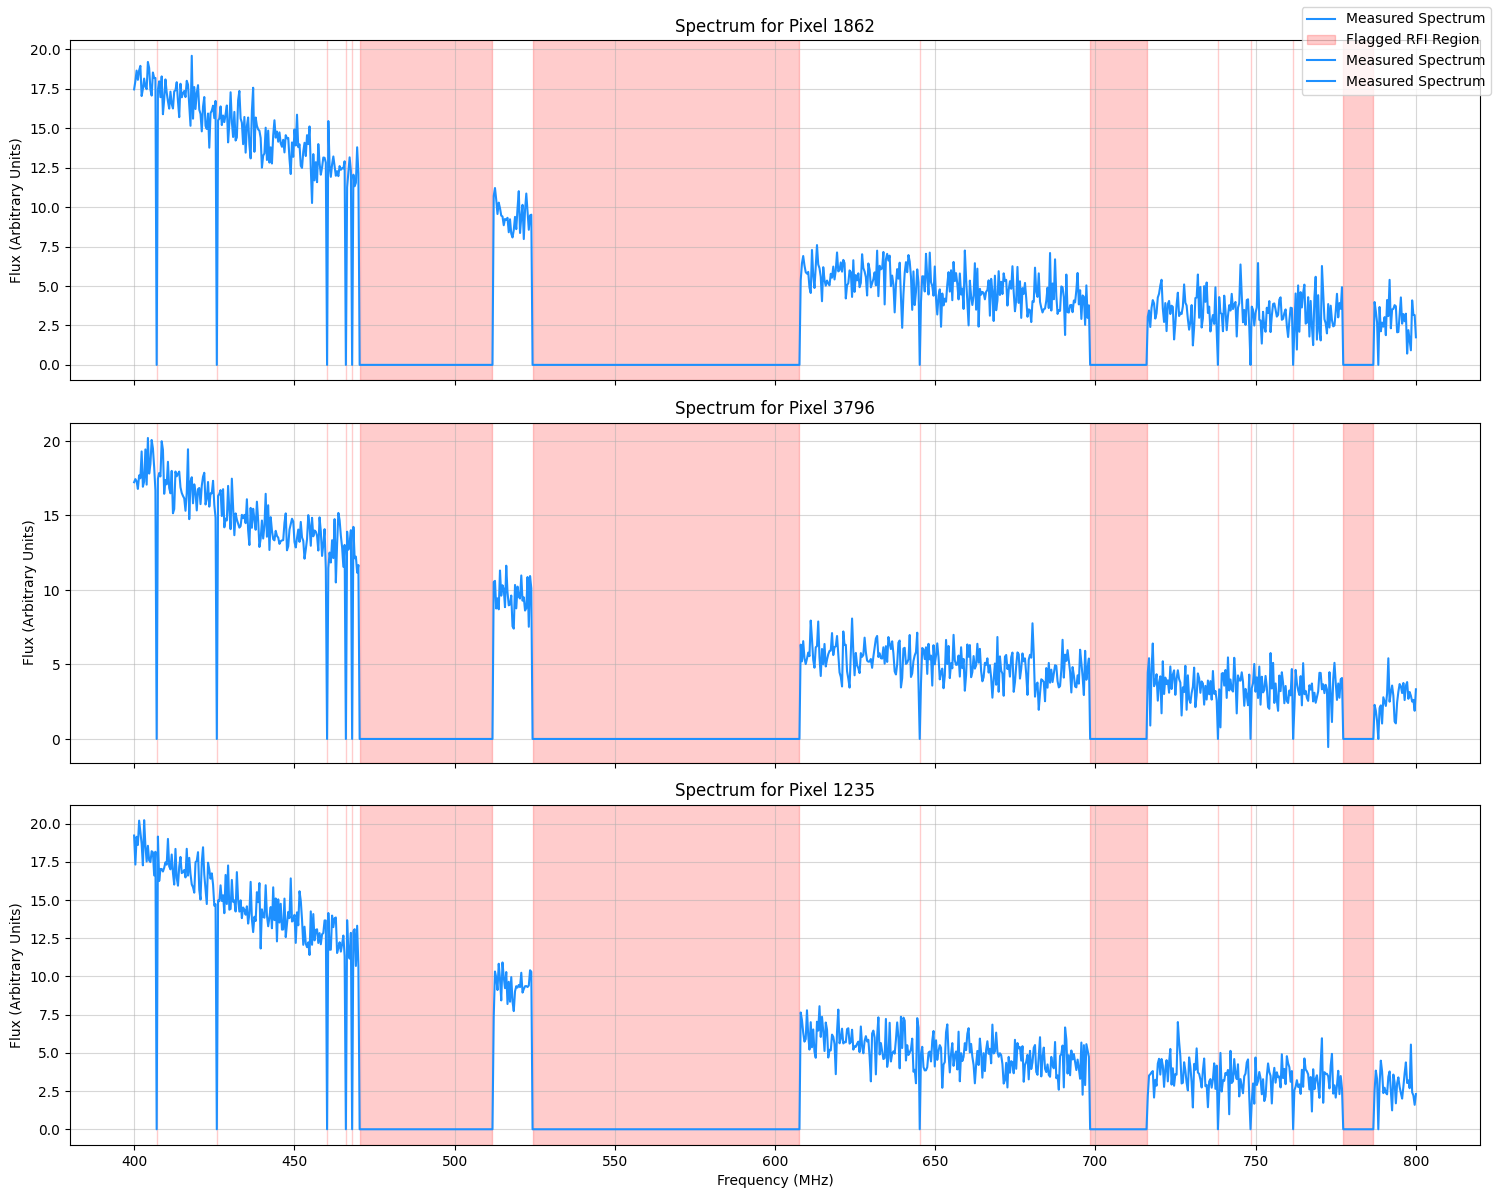

In [8]:
print("--- Displaying Sample Spectra with RFI Masking ---")

# Select a few random pixels to inspect
num_to_plot = 3
pixel_indices_to_plot = np.random.choice(N_PIXELS, num_to_plot, replace=False)

# Create the plot
fig, axes = plt.subplots(num_to_plot, 1, figsize=(15, 4 * num_to_plot), sharex=True)
if num_to_plot == 1:
    axes = [axes] # Ensure axes is always iterable

for i, pixel_idx in enumerate(pixel_indices_to_plot):
    ax = axes[i]
    
    # Plot the spectrum from the data cube
    ax.plot(FREQS_MHZ, data_cube[pixel_idx, :], color='dodgerblue', label='Measured Spectrum')
    
    # Highlight the flagged RFI regions in red
    # `rfi_mask_boolean` is True for GOOD channels, so we plot where it's False
    flagged_indices = np.where(~rfi_mask_boolean)[0]
    
    # To avoid plotting thousands of individual lines, we can find contiguous blocks
    for start in np.where(np.diff(flagged_indices) > 1)[0]:
        end_idx = flagged_indices[start]
        start_idx = flagged_indices[np.where(np.diff(flagged_indices) > 1)[0][np.where(np.where(np.diff(flagged_indices) > 1)[0] == start)[0][0]-1]+1] if start !=0 else flagged_indices[0]
        ax.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.2, label='Flagged RFI Region' if i == 0 and start == np.where(np.diff(flagged_indices) > 1)[0][0] else "")


    ax.set_title(f'Spectrum for Pixel {pixel_idx}')
    ax.set_ylabel('Flux (Arbitrary Units)')
    ax.grid(True, alpha=0.5)

ax.set_xlabel('Frequency (MHz)')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

--- Displaying Sample Spectra with RFI Masking and Infilling---


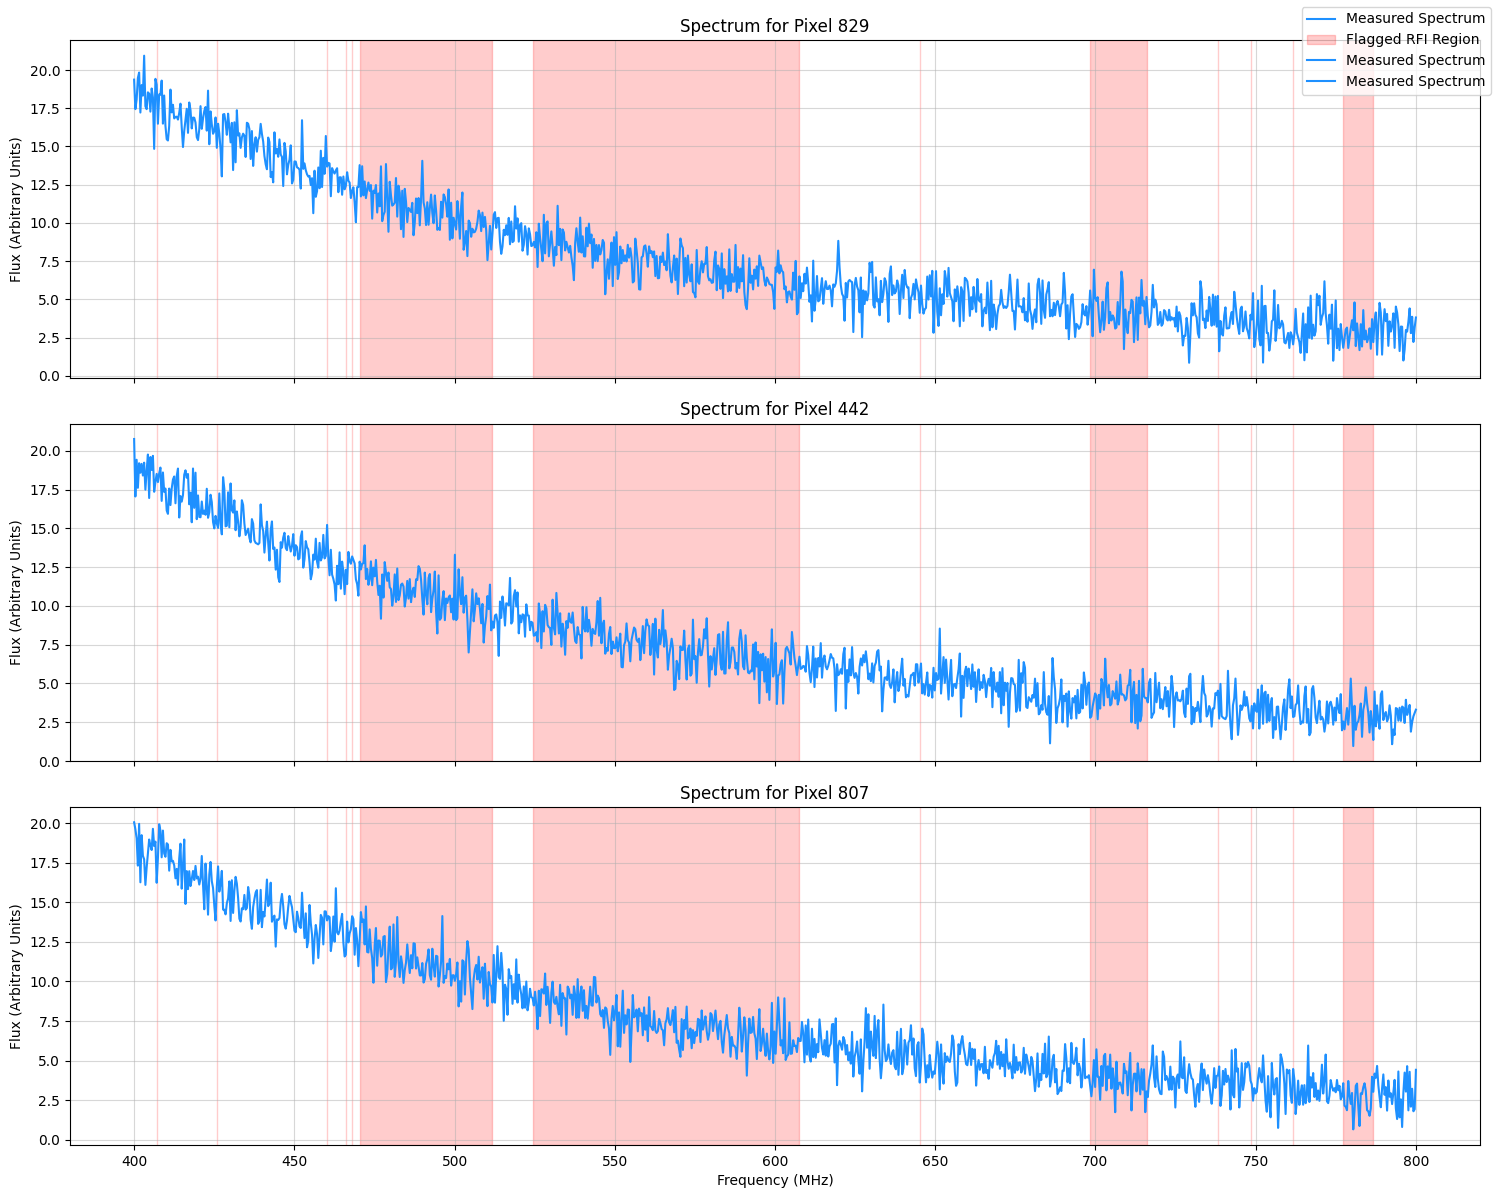

In [9]:
print("--- Displaying Sample Spectra with RFI Masking and Infilling---")

# Select a few random pixels to inspect
num_to_plot = 3
pixel_indices_to_plot = np.random.choice(N_PIXELS, num_to_plot, replace=False)

# Create the plot
fig, axes = plt.subplots(num_to_plot, 1, figsize=(15, 4 * num_to_plot), sharex=True)
if num_to_plot == 1:
    axes = [axes] # Ensure axes is always iterable

for i, pixel_idx in enumerate(pixel_indices_to_plot):
    ax = axes[i]
    
    # Plot the spectrum from the data cube
    infilled_spectrum = oss.infill_rfi(spectrum=data_cube[pixel_idx, :],frequencies=FREQS_MHZ, weights=rfi_mask_boolean)
    ax.plot(FREQS_MHZ, infilled_spectrum, color='dodgerblue', label='Measured Spectrum')
    
    # Highlight the flagged RFI regions in red
    # `rfi_mask_boolean` is True for GOOD channels, so we plot where it's False
    flagged_indices = np.where(~rfi_mask_boolean)[0]
    
    # To avoid plotting thousands of individual lines, we can find contiguous blocks
    for start in np.where(np.diff(flagged_indices) > 1)[0]:
        end_idx = flagged_indices[start]
        start_idx = flagged_indices[np.where(np.diff(flagged_indices) > 1)[0][np.where(np.where(np.diff(flagged_indices) > 1)[0] == start)[0][0]-1]+1] if start !=0 else flagged_indices[0]
        ax.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.2, label='Flagged RFI Region' if i == 0 and start == np.where(np.diff(flagged_indices) > 1)[0][0] else "")


    ax.set_title(f'Spectrum for Pixel {pixel_idx}')
    ax.set_ylabel('Flux (Arbitrary Units)')
    ax.grid(True, alpha=0.5)

ax.set_xlabel('Frequency (MHz)')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Foreground Subtraction with a Delay Filter

The most significant contaminant in our data, even more so than instrumental noise, is the sky itself. Our galaxy and distant radio sources produce incredibly bright foreground emission that is smooth in frequency. This smooth-spectrum emission can be thousands of times brighter than the faint, narrow-band OHM signals we are searching for.

To detect our signals, we must first remove this overwhelming foreground. We can achieve this by transforming our data from the frequency domain into the **delay domain**.

#### What is Delay Space? ⏳

A Fourier transform of a frequency spectrum produces its corresponding "delay spectrum." In this delay space, a signal's properties are mapped differently:

  * **Spectrally Smooth Signals**: Bright, smooth-spectrum sources (like our foregrounds) have very little variation across frequency. In delay space, this means their power is highly concentrated at the origin, at **low delays** (near 0 ns).
  * **Spectrally Complex Signals**: Faint, narrow-band signals (like our OHM masers) have sharp, complex features in the frequency domain. In delay space, this complexity spreads their power far from the origin, out to **high delays**.

#### The Delay Filter

This separation allows us to apply a powerful filter. We perform a Fourier transform on the data, set a "notch" at the center to remove everything at low delay (the foregrounds), and then transform the data back to the frequency domain. The result is a "delay-filtered" spectrum where the bright, smooth foregrounds have been effectively subtracted, allowing the faint, high-delay maser signals to become visible. We will use a **250 ns** delay cut, which is a strong filter designed to aggressively remove foregrounds.

-----

### Applying the Delay Filter


In [10]:
# --- Applying Delay Filter with Two-Pass Robust Noise Estimation ---

# --- Pass 1: Calibration Step to Get a Stable Global Noise Estimate ---
print("--- Pass 1: Calibrating a stable global noise estimate ---")
MASK_BRIGHT_SOURCES = False
SIGMA_THRESHOLD = 7.0
# NEW: Define the number of channels to mask on each side of a bright source
MASKING_BANDWIDTH = 5
DELAY_CUT_NS = 200.0
# Identify "cold" pixels where no signals were injected
all_pixel_indices = set(range(N_PIXELS))
injection_pixel_indices = set(g['pixel_index'] for g in ground_truth['injections'])
cold_pixel_indices = list(all_pixel_indices - injection_pixel_indices)

# We'll run the full pipeline on a subset of these cold pixels
num_calibration_pixels = min(200, len(cold_pixel_indices))
calibration_pixels = np.random.choice(cold_pixel_indices, num_calibration_pixels, replace=False)

noise_std_history = []

for i in tqdm(calibration_pixels, desc="Calibrating Noise"):
    # Run the full FFT filtering chain on a cold pixel
    temp_infilled = oss.infill_rfi_iterative(data_cube[i, :], rfi_mask_boolean, FREQS_MHZ)
    temp_filtered = oss.apply_windowed_delay_filter(
        spectrum=temp_infilled,
        weights=np.ones_like(temp_infilled), # Use uniform weights for filtering
        freqs_mhz=FREQS_MHZ,
        delay_cut_ns=DELAY_CUT_NS
    )
    # The std dev of the final filtered noise is what we want
    noise_std_history.append(np.std(temp_filtered))

# Our stable global estimate is the median of these measurements
stable_global_noise_std = np.median(noise_std_history)
print(f"  - Stable Global Noise Sigma calibrated to be: {stable_global_noise_std:.3f}")


# --- Pass 2: Main Filtering Loop Using the Stable Global Estimate ---
print("\n--- Pass 2: Applying Windowed Delay Filter to Full Data Cube ---")
DELAY_CUT_NS = 200.0
delay_filtered_cube = np.zeros_like(data_cube)

for i in tqdm(range(N_PIXELS), desc=f"Applying {DELAY_CUT_NS}ns Windowed Filter"):
    # Step 1: Infill RFI using the stable global noise estimate
    infilled_spectrum = oss.infill_rfi_iterative(
        spectrum=data_cube[i, :],
        weights=rfi_mask_boolean,
        frequencies=FREQS_MHZ,
        global_noise_sigma=stable_global_noise_std # Pass the stable estimate
    )
    
    # Step 2: Apply the windowed delay filter to the infilled spectrum
    delay_filtered_cube[i, :] = oss.apply_windowed_delay_filter(
        spectrum=infilled_spectrum,
        weights=np.ones_like(infilled_spectrum), # Use uniform weights
        freqs_mhz=FREQS_MHZ,
        delay_cut_ns=DELAY_CUT_NS
    )

print("\nDelay filtering complete.")

# --- Sanity Check ---
std_before = np.std(data_cube)
std_after = np.std(delay_filtered_cube)
print(f"\nStandard deviation before filtering: {std_before:.2f}")
print(f"Standard deviation after filtering:  {std_after:.2f}")

--- Pass 1: Calibrating a stable global noise estimate ---


Calibrating Noise:   0%|          | 0/200 [00:00<?, ?it/s]

  - Stable Global Noise Sigma calibrated to be: 1.086

--- Pass 2: Applying Windowed Delay Filter to Full Data Cube ---


Applying 200.0ns Windowed Filter:   0%|          | 0/4096 [00:00<?, ?it/s]


Delay filtering complete.

Standard deviation before filtering: 5.46
Standard deviation after filtering:  1.09


In [48]:
np.save('FFT_delay_cube', delay_filtered_cube)

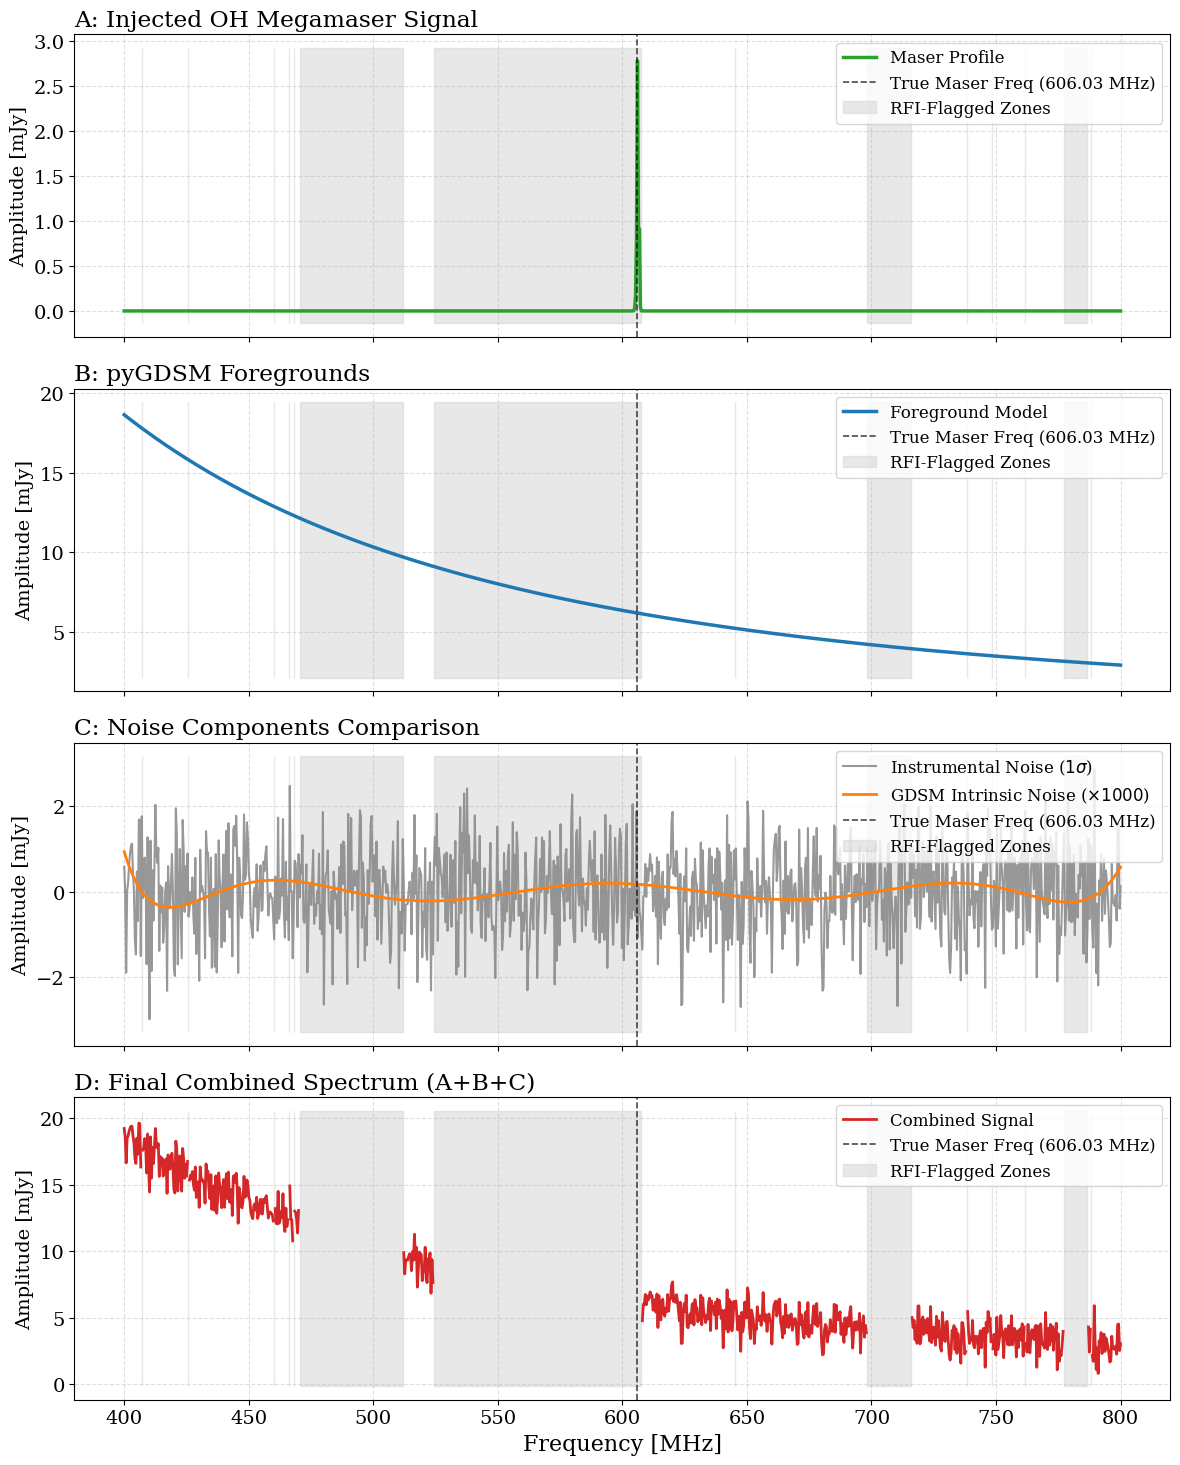

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyfit, polyval

# --- 1. Setup and Data Extraction ---
# Select a representative injection to plot
injection_index = 5
g_truth = ground_truth['injections'][injection_index]
pixel_idx = g_truth['pixel_index']
true_freq = oss.z_to_freq(g_truth['z'])

# Extract the individual components for this pixel
# a) The pure, noiseless maser signal
maser_signal = g_truth['noiseless_profile']

# b) The clean GDSM foregrounds for this pixel
foreground_component = foreground_cube[pixel_idx, :]

# c) The clean instrumental noise component for this pixel
noise_component = noise_cube[pixel_idx, :]

# d) The final combined spectrum
final_spectrum = data_cube[pixel_idx, :]

# e) NEW: Calculate the GDSM intrinsic noise for this pixel
# Fit and subtract a smooth polynomial to isolate the small-scale residuals
coeffs = polyfit(FREQS_MHZ, foreground_component, deg=7)
smooth_foreground_model = polyval(FREQS_MHZ, coeffs)
gdsm_intrinsic_noise = foreground_component - smooth_foreground_model

# --- 2. Create the Figure ---
plt.rcParams.update({'font.size': 14, 'font.family': 'serif'})
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
# fig.suptitle("Components of a Single Simulated Line of Sight", fontsize=22, y=0.95)

# --- 3. Plot Each Panel ---

# Panel A: Injected OHM Signal
axes[0].plot(FREQS_MHZ, maser_signal, color='C2', lw=2.5, label='Maser Profile')
axes[0].set_ylabel("Amplitude [mJy]")
axes[0].set_title("A: Injected OH Megamaser Signal", loc='left')

# Panel B: GDSM Foregrounds
axes[1].plot(FREQS_MHZ, foreground_component, color='C0', lw=2.5, label='Foreground Model')
axes[1].set_ylabel("Amplitude [mJy]")
axes[1].set_title("B: pyGDSM Foregrounds", loc='left')

# Panel C: Noise Components (UPDATED)
axes[2].plot(FREQS_MHZ, noise_component, color='C7', lw=1.5, alpha=0.8, label=r'Instrumental Noise ($1 \sigma$)')
axes[2].plot(FREQS_MHZ, gdsm_intrinsic_noise*1000, color='C1', lw=2.0, label=r'GDSM Intrinsic Noise ($\times 1000$)')
axes[2].set_ylabel("Amplitude [mJy]")
axes[2].set_title("C: Noise Components Comparison", loc='left')

# Panel D: Combined Data (Final Spectrum)
# remove the zeros
spectrum_masked = np.where(final_spectrum == 0, np.nan, final_spectrum)
axes[3].plot(FREQS_MHZ, spectrum_masked, color='C3', lw=2.0, label='Combined Signal')
axes[3].set_xlabel("Frequency [MHz]", fontsize=16)
axes[3].set_ylabel("Amplitude [mJy]")
axes[3].set_title("D: Final Combined Spectrum (A+B+C)", loc='left')

# --- 4. Add Enhancements to All Panels ---
for ax in axes:
    ax.axvline(true_freq, color='k', linestyle='--', lw=1.2, alpha=0.7, label=f'True Maser Freq ({true_freq:.2f} MHz)')
    ax.fill_between(FREQS_MHZ, ax.get_ylim()[0], ax.get_ylim()[1], where=(~rfi_mask_boolean),
                     color='lightgrey', alpha=0.5, label='RFI-Flagged Zones', step='mid')
    ax.legend(loc='upper right', fontsize=12)
    ax.grid(True, which="both", ls="--", alpha=0.4)
    # ax.set_xlim(true_freq - 25, true_freq + 25)

# --- 5. Final Touches and Display ---
plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig('simulation_decomposition.jpeg', dpi=150)
plt.show()

--- Displaying Sample Spectra with RFI Masking ---


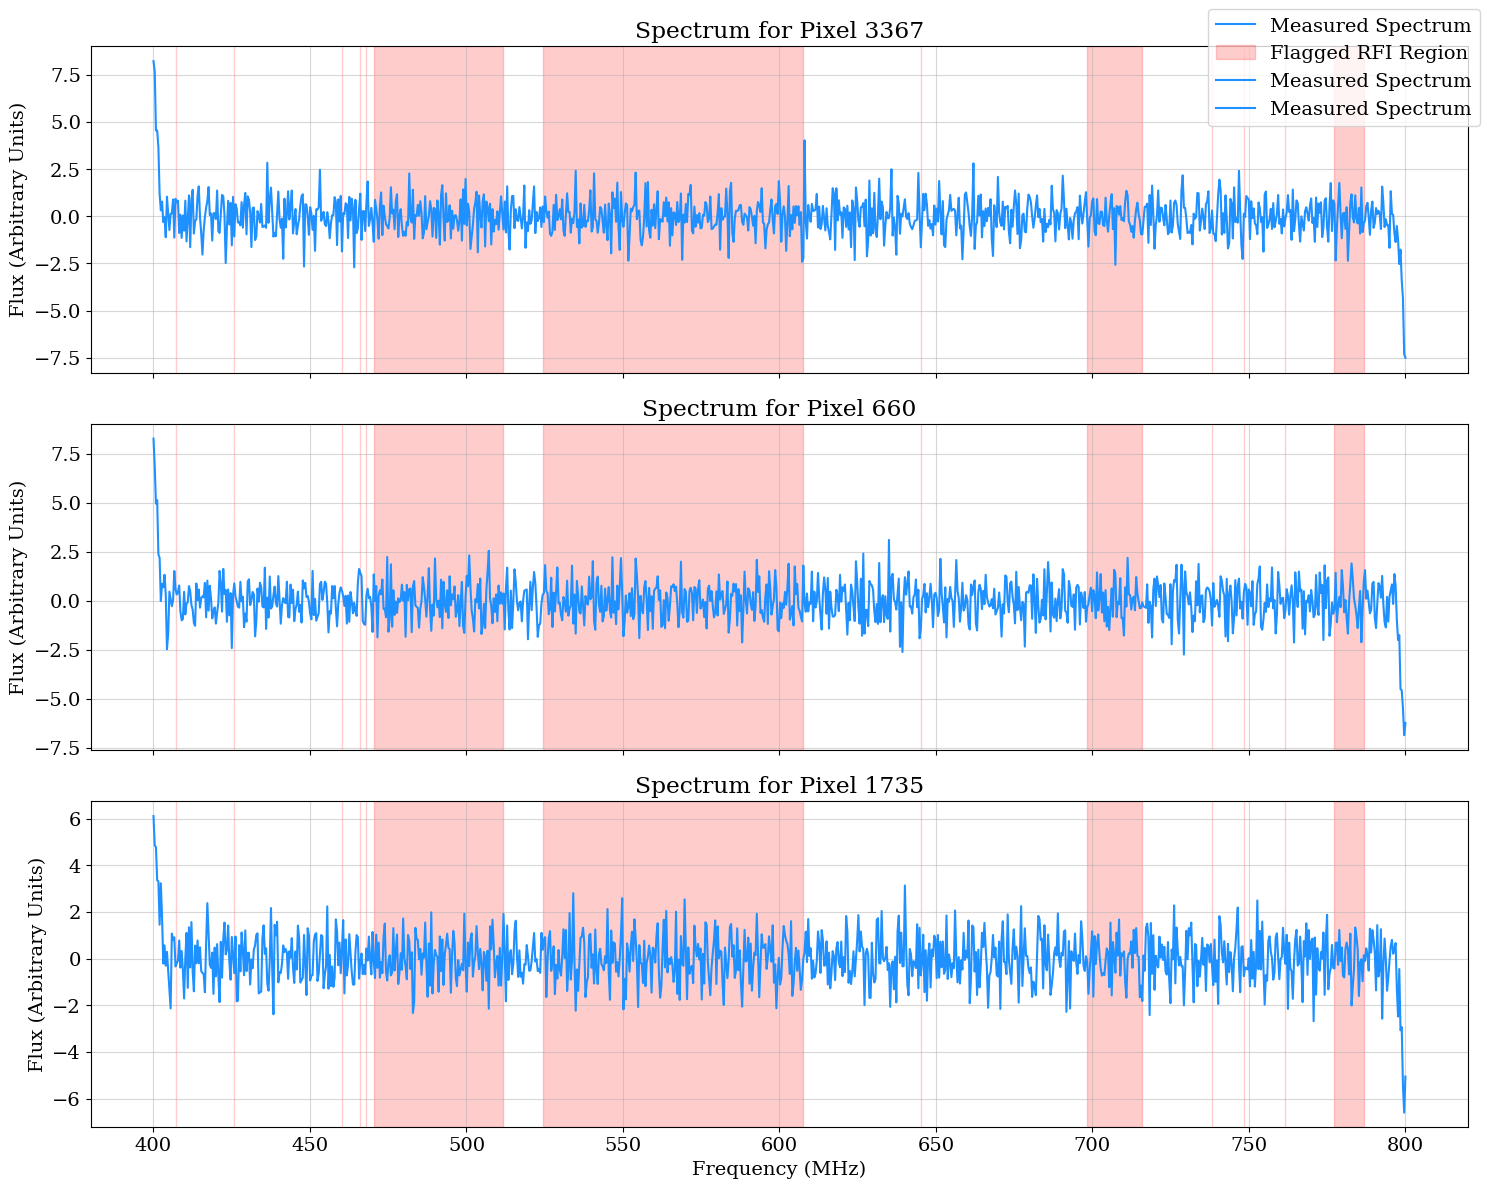

In [15]:
print("--- Displaying Sample Spectra with RFI Masking ---")

# Select a few random pixels to inspect
num_to_plot = 3
pixel_indices_to_plot = np.random.choice(N_PIXELS, num_to_plot, replace=False)

# Create the plot
fig, axes = plt.subplots(num_to_plot, 1, figsize=(15, 4 * num_to_plot), sharex=True)
if num_to_plot == 1:
    axes = [axes] # Ensure axes is always iterable

for i, pixel_idx in enumerate(pixel_indices_to_plot):
    ax = axes[i]
    
    # Plot the spectrum from the data cube
    ax.plot(FREQS_MHZ, delay_filtered_cube[pixel_idx, :], color='dodgerblue', label='Measured Spectrum')
    
    # Highlight the flagged RFI regions in red
    # `rfi_mask_boolean` is True for GOOD channels, so we plot where it's False
    flagged_indices = np.where(~rfi_mask_boolean)[0]
    
    # To avoid plotting thousands of individual lines, we can find contiguous blocks
    for start in np.where(np.diff(flagged_indices) > 1)[0]:
        end_idx = flagged_indices[start]
        start_idx = flagged_indices[np.where(np.diff(flagged_indices) > 1)[0][np.where(np.where(np.diff(flagged_indices) > 1)[0] == start)[0][0]-1]+1] if start !=0 else flagged_indices[0]
        ax.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.2, label='Flagged RFI Region' if i == 0 and start == np.where(np.diff(flagged_indices) > 1)[0][0] else "")


    ax.set_title(f'Spectrum for Pixel {pixel_idx}')
    ax.set_ylabel('Flux (Arbitrary Units)')
    ax.grid(True, alpha=0.5)

ax.set_xlabel('Frequency (MHz)')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

***

## Why Infill RFI for a Matched Filter? The Need for Speed ⚡

You might ask: "If the Dayenu filter is so robust to RFI-flagged gaps, why bother infilling them at all?"

The answer comes down to a trade-off between **robustness** and **computational speed**, especially when performing a blind search with a matched filter. While Dayenu is robust, it can be computationally intensive. For the subsequent matched filter search, we can gain a massive speed-up by using the Fast Fourier Transform (FFT), but the FFT has one critical weakness: it requires complete, uninterrupted data.

### The Convolution Theorem: A Mathematical Shortcut

A matched filter is mathematically a **cross-correlation**. A blind search involves correlating a template, $t(\nu)$, across your entire spectrum, $d(\nu)$. In the frequency domain, this is a slow, "direct summation" operation that scales poorly for large datasets, approximately as $\mathcal{O}(N^2)$.

However, a beautiful mathematical property called the **Convolution Theorem** provides a much faster path. It states that a cross-correlation in the frequency domain is equivalent to a simple element-wise multiplication in the Fourier (delay) domain.

$$(d \star t)(\tau) \Longleftrightarrow \mathcal{F}\{d\}^* \cdot \mathcal{F}\{t\}$$

Here, $\star$ is the cross-correlation, $\mathcal{F}$ is the Fourier Transform, and the asterisk ($^*$) denotes the complex conjugate.

By using the Fast Fourier Transform (FFT) algorithm, which scales as $\mathcal{O}(N \log N)$, we can perform the entire matched filter search dramatically faster. The process becomes:
1.  FFT the data and the template.
2.  Perform one simple multiplication.
3.  Inverse FFT the result to get the full SNR spectrum.

This is the method used by `run_matched_filter_fft`. But to use the FFT, the input arrays must be complete. **This is where infilling becomes essential.** By replacing the RFI-flagged gaps with plausible data, we create a complete array that unlocks the speed of the FFT for our matched filter search.

### A Historical Tidbit: The Secret History of the FFT 📜

The modern FFT algorithm, which sparked the digital signal processing revolution, is most famously credited to **James Cooley** and **John Tukey** from their 1965 paper. It was a groundbreaking development that made digital analysis of signals practical for the first time.

However, the core mathematical idea is much older! The brilliant mathematician **Carl Friedrich Gauss** actually developed a very similar method around **1805**—over 150 years earlier. He used it by hand to calculate the orbits of the asteroids Pallas and Juno. His work was published after his death but was largely overlooked until Cooley and Tukey's independent rediscovery.

The matched filter itself also has a fascinating origin. It was developed during **World War II** around 1943 by **Dwight O. North** at RCA Laboratories. Its purpose was to design the optimal receiver to maximize the signal-to-noise ratio for detecting faint radar echoes in the presence of random noise, a concept that is fundamental to signal detection theory to this day.

-----

### Interactive Viewer: Before and After Delay Filtering

To build intuition for how our foreground filter works, this interactive plot allows you to compare spectra from the same pixel side-by-side.

  * **The Left Panel** shows the raw spectrum from the GDSM simulation, including the bright, smooth foreground component.
  * **The Right Panel** shows the same spectrum *after* the **250 ns** delay filter has been applied.

Notice how the large-scale, smooth structure is removed, leaving behind what is essentially flat, Gaussian-like noise. The standard deviation ($\\sigma$) of the flux, printed in the corner of each plot, provides a quantitative measure of this effect. The goal of the filter is to dramatically reduce the standard deviation of the data before we search for faint signals.

Use the slider to explore different pixels in the simulated sky.

-----


In [45]:
from ipywidgets import interact, IntSlider
import warnings

# Suppress minor warnings from matplotlib to keep the output clean
warnings.filterwarnings("ignore", category=UserWarning)

def plot_spectral_comparison(pixel_index):
    """
    An interactive plotting function to compare a spectrum before and
    after delay filtering for a given pixel.
    """
    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    fig.suptitle(f'Spectral Comparison for Pixel {pixel_index}', fontsize=16)

    # --- 1. Before Filtering ---
    spec_before = data_cube[pixel_index, :]
    std_before = np.std(spec_before[spec_before != 0]) # Exclude RFI-masked zeros
    ax1.plot(FREQS_MHZ, spec_before, color='firebrick', label='Before Filter')
    ax1.set_title('Before Filtering (Raw GDSM + Noise)')
    ax1.set_xlabel('Frequency (MHz)')
    ax1.set_ylabel('Flux (Arbitrary Units)')
    ax1.grid(True, alpha=0.5)
    # Display the standard deviation in the top-left corner
    ax1.text(0.02, 0.95, f'σ = {std_before:.2f}', transform=ax1.transAxes, 
             ha='left', va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.8))

    # --- 2. After Filtering ---
    spec_after = delay_filtered_cube[pixel_index, :]
    std_after = np.std(spec_after[spec_after != 0]) # Exclude RFI-masked zeros
    ax2.plot(FREQS_MHZ, spec_after, color='dodgerblue', label='After Filter')
    ax2.set_title('After Filtering (Foregrounds Removed)')
    ax2.set_xlabel('Frequency (MHz)')
    ax2.grid(True, alpha=0.5)
    # Display the standard deviation in the top-left corner
    ax2.text(0.02, 0.95, f'σ = {std_after:.2f}', transform=ax2.transAxes, 
             ha='left', va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.8))

    # Overlay the RFI mask on both plots for context
    if 'rfi_mask_boolean' in globals():
        flagged_indices = np.where(~rfi_mask_boolean)[0]
        for start in np.where(np.diff(flagged_indices) > 1)[0]:
            end_idx = flagged_indices[start]
            start_idx = flagged_indices[np.where(np.diff(flagged_indices) > 1)[0][np.where(np.where(np.diff(flagged_indices) > 1)[0] == start)[0][0]-1]+1] if start !=0 else flagged_indices[0]
            ax1.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.1)
            ax2.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.1)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- Create the Interactive Slider ---
interact(
    plot_spectral_comparison,
    pixel_index=IntSlider(min=0, max=N_PIXELS - 1, step=1, value=0, description='Pixel Index:')
);

interactive(children=(IntSlider(value=0, description='Pixel Index:', max=4095), Output()), _dom_classes=('widg…

Of course. That's an excellent idea. Visualizing the data in the image domain is just as important as viewing the spectra. This will allow you to scroll through the frequency channels and see how the spatial structure of the sky changes, especially how the bright foregrounds are removed by the delay filter.

Here are the markdown and Python cells to create this new interactive image viewer.

### Interactive Viewer: Image Slices vs. Frequency

This interactive viewer provides a different perspective on our data cube. Instead of looking at the spectrum for one pixel, we are now looking at the entire **2D sky image** at a **single frequency channel**.

  * **The Left Panel** shows the raw sky image at a specific frequency, including the GDSM foregrounds.
  * **The Right Panel** shows the same sky image *after* the delay filter has been applied.

Use the slider to scroll through the different frequency channels of the telescope. Notice how in the "Before" panel, the image is dominated by large-scale power from the foregrounds, while the "After" panel shows what is effectively a map of the instrumental noise. This viewer also tells you if the channel you are currently viewing is flagged for RFI.

-----

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import cmocean
import warnings

# Suppress minor warnings from matplotlib to keep the output clean
warnings.filterwarnings("ignore", category=UserWarning)

def plot_image_comparison(frequency_index):
    """
    An interactive plotting function to compare a 2D sky image before and
    after delay filtering for a given frequency channel.
    """
    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Determine the frequency and RFI status for the title
    freq_mhz = FREQS_MHZ[frequency_index]
    is_flagged = not rfi_mask_boolean[frequency_index]
    rfi_status_str = "FLAGGED FOR RFI" if is_flagged else "Clean"
    
    fig.suptitle(f'Sky Image at {freq_mhz:.2f} MHz (Channel {frequency_index}) | Status: {rfi_status_str}', 
                 fontsize=16, color='red' if is_flagged else 'black')

    # --- 1. Before Filtering ---
    # Get the image slice for this frequency and reshape it to our 2D grid
    img_before = foreground_cube[:, frequency_index].reshape(GRID_SHAPE)
    im1 = ax1.imshow(img_before, cmap=cmocean.cm.thermal, origin='lower', aspect='auto')
    ax1.set_title('Before Filtering (Raw GDSM + Noise)')
    ax1.set_xlabel('Pixel X-coordinate')
    ax1.set_ylabel('Pixel Y-coordinate')
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Flux')

    # --- 2. After Filtering ---
    img_after = delay_filtered_cube[:, frequency_index].reshape(GRID_SHAPE)
    # Use the same color scale for a fair comparison
    im2 = ax2.imshow(img_after, cmap=cmocean.cm.thermal, origin='lower', aspect='auto')#, 
                     #vmin=np.min(img_before), vmax=np.max(img_before))
    ax2.set_title('After Filtering (Foregrounds Removed)')
    ax2.set_xlabel('Pixel X-coordinate')
    ax2.set_ylabel('') # Hide y-axis label for clarity
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Flux')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# --- Create the Interactive Slider ---
interact(
    plot_image_comparison,
    frequency_index=IntSlider(min=0, max=len(FREQS_MHZ) - 1, step=1, value=len(FREQS_MHZ)//2, description='Frequency Channel:')
);

interactive(children=(IntSlider(value=512, description='Frequency Channel:', max=1023), Output()), _dom_classe…

## Part 4: Matched Filtering and SNR Cube Generation

This is the core of the search pipeline. We apply a matched filter to our simulated data cube. The matched filter correlates the data with a set of pre-computed templates that model the expected signal shape at different redshifts.

The output is a 3D Signal-to-Noise (SNR) cube of the same dimensions as the data cube. Each voxel in this cube represents the SNR of the best-matching template at that specific sky position and frequency.

Of course! Here is a detailed markdown cell explaining the matched filter algorithm and the SNR boost calculation, complete with LaTeX equations.

***
### The Direct-Match, Multi-Template Matched Filter

Our pipeline employs a specialized matched filter designed for both efficiency and precision. Unlike a traditional approach that slides every template across the entire frequency spectrum (a full cross-correlation), our **direct-match** method tests each template only at its specific, corresponding frequency location. This provides a massive speed advantage while maintaining the core benefits of matched filtering.

The process can be broken down into four main steps:

---
#### Step 1: Building the Template Bank 🏦

The foundation of the search is a bank of realistic OHM signal templates. To avoid redundant calculations, we use a "generate once, transform many" approach:

1.  **Master Template Creation**: A single, high-resolution "master" template, $T_{\text{intrinsic}}(v)$, is generated in velocity space. This captures the intrinsic, double-peaked profile of a typical OHM signal.

2.  **Redshift Transformation**: This master template is then transformed to create a unique template for each redshift, $z$, in our search grid. This transformation maps the velocity profile to the observed frequency grid, $f_{\text{native}}$, accounting for the cosmological redshift:

    $T_z(f_{\text{native}}) = \text{transform}(T_{\text{intrinsic}}(v), z, f_{\text{native}})$

---
#### Step 2: The Direct-Match Search Algorithm 🎯

For each pixel in the sky, we take its measured frequency spectrum, $D(f)$, and test it against every template, $T_z$, in our bank. The core of the matched filter is the calculation of the Signal-to-Noise Ratio (SNR) for each template at its specific location. This is calculated as a normalized **inner product** (or dot product).

For a given template, $T_z$, which spans a specific range of frequency channels, the SNR is given by:

$\text{SNR}_z = \frac{\sum_{i} D_i \cdot T_{z,i}}{\sigma_{\text{noise}} \sqrt{\sum_{i} T_{z,i}^2}}$

where:
- $D_i$ is the data (flux) in the $i$-th frequency channel that the template overlaps.
- $T_{z,i}$ is the value of the template in that same channel.
- $\sigma_{\text{noise}}$ is the standard deviation (RMS) of the background noise.
- The term $\sqrt{\sum_{i} T_{z,i}^2}$ is the L2-norm (or "energy") of the template, which serves to properly normalize the result.

This calculation is performed for every template in the bank.

---
#### Step 3: Constructing the SNR Cube 🧊

As we calculate the SNR for each template, we build the final 3D Signal-to-Noise cube. Our algorithm "paints" the calculated SNR value across all the frequency channels that the corresponding template occupies.

Crucially, we only update a voxel's value if the new SNR is greater than the value already stored there. This ensures that for any given position in the cube, the final value represents the SNR of the **best-matching template** that overlaps that position.

---
#### Step 4: Predicting the SNR Boost ✨

A key validation step is to predict the theoretical SNR boost a signal *should* receive from the matched filter. This prediction tells us how much a signal with a known amplitude will be amplified relative to the noise.

For a noiseless injected signal, $S$, with a peak amplitude of $A_{\text{peak}}$, its theoretical SNR after filtering is:

$\text{Predicted SNR} = \frac{\sum_{i} S_i \cdot T_{S,i}}{\sigma_{\text{noise}} \sqrt{\sum_{i} T_{S,i}^2}}$

Here, $T_{S,i}$ is the **perfectly matched template** for that signal. Since the signal itself is just a scaled version of its perfect template ($S_i = A_{\text{peak}} \cdot T_{S,i}$), the equation simplifies beautifully:

$\text{Predicted SNR} = \frac{A_{\text{peak}} \sum_{i} T_{S,i}^2}{\sigma_{\text{noise}} \sqrt{\sum_{i} T_{S,i}^2}} = \frac{A_{\text{peak}}}{\sigma_{\text{noise}}} \sqrt{\sum_{i} T_{S,i}^2}$

This elegant result shows that the expected SNR is simply the signal's intrinsic SNR ($A_{\text{peak}}/\sigma_{\text{noise}}$) multiplied by the **energy of the normalized template**. This is the value we use to calculate the "Predicted True Positives" and to create the "Theoretical SNR" histogram.


#### 1. Peak SNR (Used for Detection)

This is the method our direct-match algorithm uses to **detect** signals and construct the initial SNR cube.

* **What it is**: The Peak SNR is the **single, maximum value** of the matched filter response. In our direct-match algorithm, the calculation `(data ⋅ template) / (σ * ||template||)` at a specific location is mathematically equivalent to finding the value at the peak of a full cross-correlation. The value we "paint" into the SNR cube represents this peak response.

* **Pros**:
    * **Simple Statistics**: The noise associated with the Peak SNR is well-described by a Gaussian distribution. This makes it straightforward to predict the false positive rate, as we have done in our analysis.
    * **Efficiency**: It is computationally simple and fast to calculate, making it ideal for the initial, brute-force search across the entire dataset.

* **Cons**:
    * **Sensitivity to Noise**: It can be sensitive to a single, unusually high or low noise value within the footprint of the signal. It doesn't use all the information across the signal's profile.

The equation we use for detection is a pure **Peak SNR**:

$\text{SNR}_{\text{peak}} = \frac{\sum_{i} D_i \cdot T_{z,i}}{\sigma_{\text{noise}} \cdot ||T_z||_2}$
*(where $||T_z||_2$ is the L2-norm)*



### Scenario 3 Matched Filter: Searching in Delay-Filtered Data

Now that the bright, smooth-spectrum foregrounds have been removed from our data cube, we can proceed with the matched filter search. However, because we have applied a linear filter (the delay filter) to our data, we must apply the **exact same filter to our templates** for the search to remain mathematically optimal.

A filter is only "matched" when the template has undergone the same processing as the signal it's trying to find. If we were to use our original, unfiltered templates to search the new, delay-filtered data, there would be a significant mismatch, and the filter's performance would be severely degraded.

The process is therefore:

1.  Generate a template for a given redshift.
2.  Apply the **250 ns** delay filter to this individual template.
3.  Calculate the normalization (energy) of this *new, filtered* template.
4.  Add the filtered template to the bank.

We then use this bank of filtered templates to search our `delay_filtered_cube`. The noise level ($\\sigma$) for the search is now calculated from this filtered cube, as it represents the true noise floor after foreground subtraction.

-----

### Matched Filter Search on Delay-Filtered Cube


In [13]:
# --- 1. Build the Filtered Template Bank ---
print("--- Building Filtered Template Bank ---")
z_grid = oss.freq_to_z(FREQS_MHZ)

# Use the new function to generate both compact and full template banks
template_bank, template_bank_full = otg.create_filtered_template_bank(
    intrinsic_template_v=intrinsic_template_v,
    vel_axis_kms=VEL_AXIS,
    z_grid=z_grid,
    native_freq_grid=FREQS_MHZ,
    delay_cut_ns=DELAY_CUT_NS
)

print(f"\nFiltered template bank created with {len(template_bank)} templates.")

--- Building Filtered Template Bank ---


Building Filtered Templates:   0%|          | 0/1024 [00:00<?, ?it/s]


Filtered template bank created with 1024 templates.



--- Running Matched Filter on Data Cube ---
  - Estimating noise with robust MAD estimator...


Applying Matched Filter to each Frequency Bin:   0%|          | 0/4096 [00:00<?, ?it/s]


SNR cube generation complete.


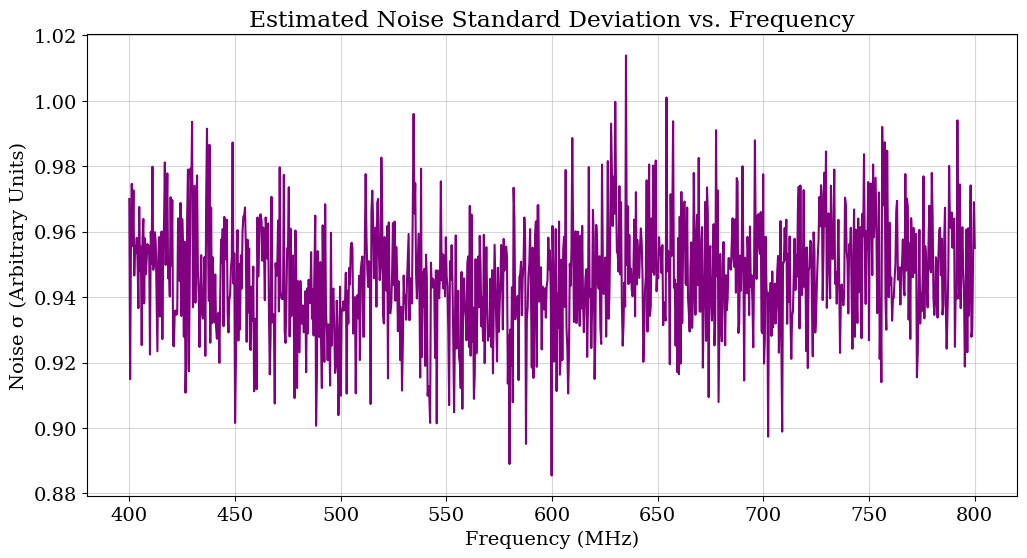

In [14]:
# --- 3. Run Matched Filter to Generate SNR Cube ---
print("\n--- Running Matched Filter on Data Cube ---")
snr_cube_3d, noise_spectrum = oss.run_matched_filter_cube(
    data_cube=delay_filtered_cube,
    template_bank_full=template_bank_full,
    weights=np.ones(len(FREQS_MHZ)) #rfi_mask_boolean, # Your RFI mask
)

print("\nSNR cube generation complete.")
# --- Sanity Check: Plot the Noise Spectrum ---
plt.figure(figsize=(12, 6))
plt.plot(FREQS_MHZ, noise_spectrum, color='purple')
plt.title('Estimated Noise Standard Deviation vs. Frequency')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Noise σ (Arbitrary Units)')
plt.grid(True, alpha=0.5)
plt.show()

In [47]:
np.save('FFT_snr_cube',snr_cube_3d)

## Part 5: 3D Candidate Finding with DBSCAN

With the SNR cube generated, we now identify significant signal candidates. Instead of simply taking the maximum SNR value in each pixel (a 2D approach), we use the **3D DBSCAN clustering algorithm**. This method treats the SNR cube as a 3D space and groups together neighboring voxels that are all above a certain SNR threshold.

This approach is more robust because:
* It is less susceptible to single-pixel noise spikes.
* It can distinguish between multiple sources at the same sky position but at different frequencies (redshifts).
* It provides a more accurate estimate of a candidate's centroid and extent in all three dimensions (sky position and frequency).

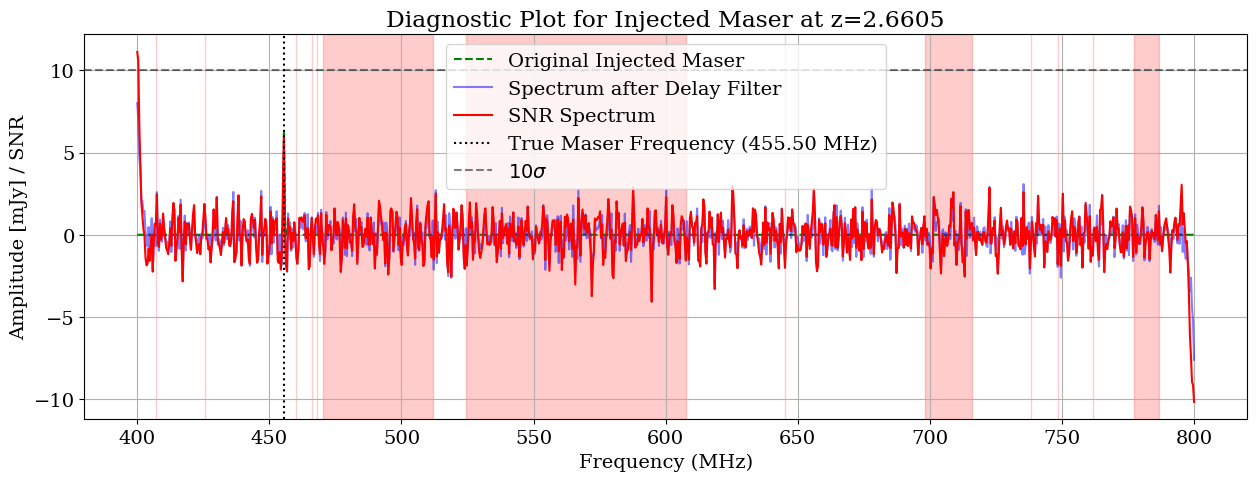

In [15]:
# Select an injected maser to inspect
injection_index = 25
pixel_idx = ground_truth['injections'][injection_index]['pixel_index']
true_z = ground_truth['injections'][injection_index]['z']
true_freq = oss.z_to_freq(true_z)

# Get the spectra
original_spectrum = ground_truth['injections'][injection_index]['noiseless_profile']
filtered_spectrum = delay_filtered_cube[pixel_idx, :]
snr_spectrum = snr_cube_3d[pixel_idx, :]

# Create the plot
plt.figure(figsize=(15, 5))
plt.plot(FREQS_MHZ, original_spectrum, label='Original Injected Maser', color='g', linestyle='--')
plt.plot(FREQS_MHZ, filtered_spectrum, label='Spectrum after Delay Filter', color='b', alpha=.5)
plt.plot(FREQS_MHZ, snr_spectrum, label='SNR Spectrum', color='r')

# Highlight the flagged RFI regions in red
# `rfi_mask_boolean` is True for GOOD channels, so we plot where it's False
flagged_indices = np.where(~rfi_mask_boolean)[0]

# To avoid plotting thousands of individual lines, we can find contiguous blocks
for start in np.where(np.diff(flagged_indices) > 1)[0]:
    end_idx = flagged_indices[start]
    start_idx = flagged_indices[np.where(np.diff(flagged_indices) > 1)[0][np.where(np.where(np.diff(flagged_indices) > 1)[0] == start)[0][0]-1]+1] if start !=0 else flagged_indices[0]
    plt.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.2, label='Flagged RFI Region' if i == 0 and start == np.where(np.diff(flagged_indices) > 1)[0][0] else "")

plt.axvline(x=true_freq, color='k', linestyle=':', label=f'True Maser Frequency ({true_freq:.2f} MHz)')
plt.axhline(y=10, color='k', linestyle='dashed', alpha=.5, label=r'$10 \sigma$')
plt.title(f'Diagnostic Plot for Injected Maser at z={true_z:.4f}')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Amplitude [mJy] / SNR')
plt.legend()
plt.grid(True)
plt.show()

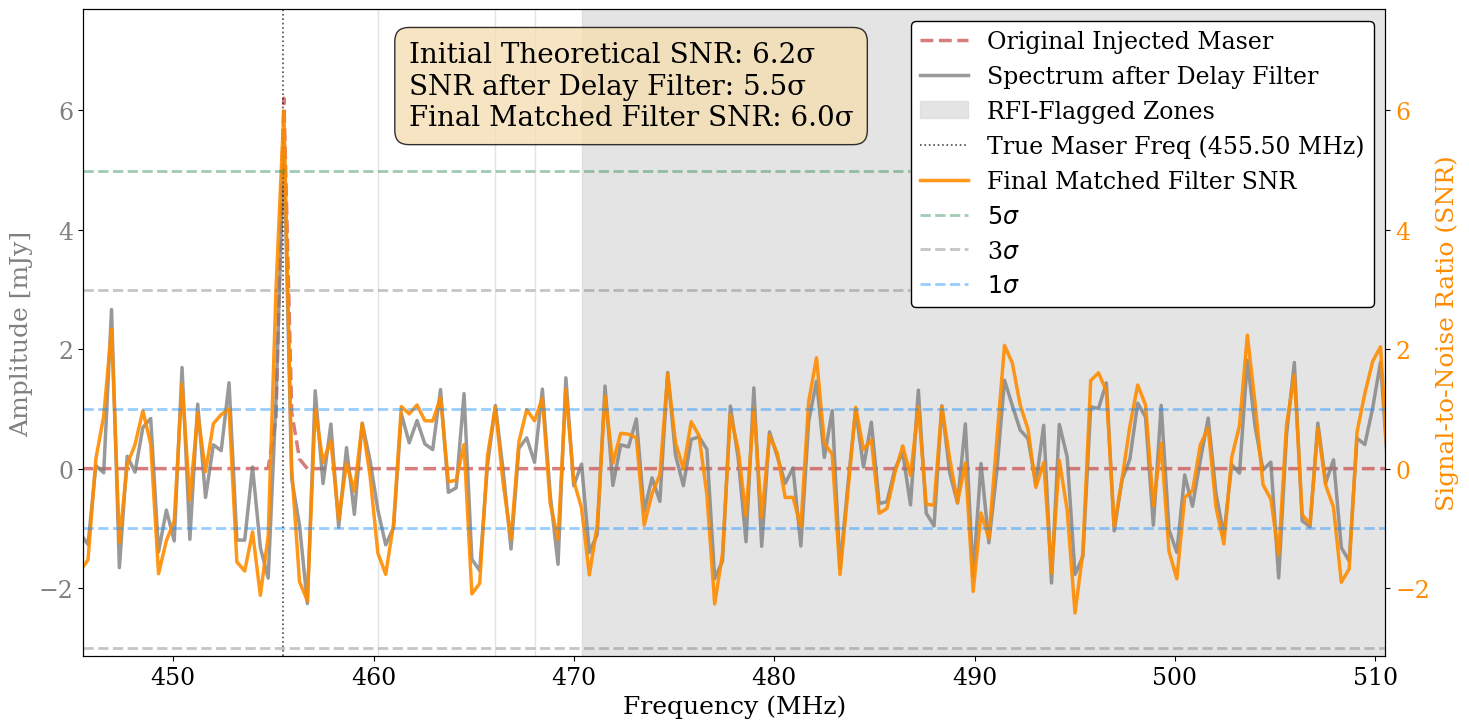

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup and Data Extraction ---
# Select an injected maser to inspect
injection_index = 25
g_truth = ground_truth['injections'][injection_index]
pixel_idx = g_truth['pixel_index']
true_z = g_truth['z']
true_freq = oss.z_to_freq(true_z)

# Get the spectra
original_spectrum = g_truth['noiseless_profile']
filtered_spectrum = delay_filtered_cube[pixel_idx, :]
snr_spectrum = snr_cube_3d[pixel_idx, :]

# --- 2. Calculate SNR at Each Stage for Annotation ---
# a) The "best case" SNR of the noiseless signal relative to the base noise
initial_snr = np.max(original_spectrum) / 1 #std_before

# b) The significance of the peak in the delay-filtered spectrum
snr_after_delay_filter = np.max(np.abs(filtered_spectrum[25:-25])) / np.std(filtered_spectrum[25:-25])

# c) The final peak SNR after the matched filter
final_snr_matched_filter = np.max(snr_spectrum[25:-25])


# --- 3. Create the Plot ---
# Set a larger, serif font for publication quality
plt.rcParams.update({'font.size': 17, 'font.family': 'serif'})
fig, ax1 = plt.subplots(figsize=(15, 8))
ax1_snr = ax1.twinx() # Create a second y-axis for SNR

# Plot the amplitude spectra on the primary (left) y-axis
ax1.plot(FREQS_MHZ, original_spectrum, label='Original Injected Maser', color='indianred', alpha=0.8, linestyle='--', lw=2.5)
ax1.plot(FREQS_MHZ, filtered_spectrum, label='Spectrum after Delay Filter', color='gray', alpha=0.8, lw=2.5)
ax1.set_xlabel('Frequency (MHz)', fontsize=18)
ax1.set_ylabel('Amplitude [mJy]', fontsize=18, color='gray')
ax1.tick_params(axis='y', labelcolor='gray')
ax1.set_ylim(-np.pi,7.7)

# Plot the SNR spectrum on the secondary (right) y-axis
ax1_snr.plot(FREQS_MHZ, snr_spectrum, label='Final Matched Filter SNR', color='darkorange', alpha=0.9, lw=2.5)
ax1_snr.set_ylabel('Signal-to-Noise Ratio (SNR)', fontsize=18, color='darkorange')
ax1_snr.tick_params(axis='y', labelcolor='darkorange')
ax1_snr.axhline(y=5*np.std(filtered_spectrum[25:-25]), lw=2, color='seagreen', xmax=.635, linestyle='dashed', alpha=0.45, label=r'$5 \sigma$')
ax1_snr.axhline(y=-5*np.std(filtered_spectrum[25:-25]), lw=2, color='seagreen', linestyle='dashed', alpha=0.45)
ax1_snr.axhline(y=3, color='gray', linestyle='dashed', lw=2, alpha=0.45, xmax=.635, label=r'3$\sigma$')
ax1_snr.axhline(y=-3, color='gray', linestyle='dashed', lw=2, alpha=0.45)#, label=r'3$\sigma$ Threshold')
ax1_snr.axhline(y=np.std(filtered_spectrum[25:-25]), lw=2, color='dodgerblue', linestyle='dashed', alpha=0.45, label=r'$1 \sigma$')
ax1_snr.axhline(y=-np.std(filtered_spectrum[25:-25]), lw=2, color='dodgerblue', linestyle='dashed', alpha=0.45)

ax1_snr.set_ylim(-np.pi,7.7)


# --- 4. Add Annotations and Labels ---
# Use a single, robust method to shade the RFI regions
ax1.fill_between(FREQS_MHZ, -1e6, 1e6, where=(~rfi_mask_boolean),
                 color='lightgrey', alpha=0.6, label='RFI-Flagged Zones', step='mid')

ax1.axvline(x=true_freq, color='k', linestyle=':', lw=1.2, alpha=.7, label=f'True Maser Freq ({true_freq:.2f} MHz)')

# Add a text box with the SNR stats
stats_text = (
    f"Initial Theoretical SNR: {initial_snr:.1f}σ\n"
    f"SNR after Delay Filter: {snr_after_delay_filter:.1f}σ\n"
    f"Final Matched Filter SNR: {final_snr_matched_filter:.1f}σ"
)
ax1.text(0.25, 0.95, stats_text, transform=ax1.transAxes, ha='left', va='top', fontsize=20,
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.8))


# --- 5. Final Touches ---
# fig.suptitle(f'Diagnostic Plot for Injected Maser at z={true_z:.4f}', fontsize=22)
# Manually combine legends from both y-axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_snr.get_legend_handles_labels()
legend = ax1.legend(lines + lines2, labels + labels2,
                    loc='upper right',
                    fontsize=17,
                    framealpha=1,
                    fancybox=True,           
                    shadow=False,              
                    frameon=True,             
                    facecolor=(1, 1, 1, 1),        
                    edgecolor='gray',
                   )        
legend.set_zorder(1000)
legend.get_frame().set_alpha(1.0)
# legend.get_frame().set_facecolor(facecolor=(1, 1, 1, 1))
legend.get_frame().set_edgecolor('black')
ax1.set_xlim(true_freq - 10, true_freq + 55) # Zoom in on the maser
fig.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make room for title
fig.savefig('matched_filter_output.jpeg', dpi=150)
plt.show()

In [17]:
# --- 9. Validate Pipeline Performance Against Ground Truth ---
print("\\n--- Validating matched filter performance using ground truth locations ---")

# This function directly checks the SNR for each injected maser
truth_validation_list = ocf.validate_from_ground_truth(
    snr_cube=snr_cube_3d,
    ground_truth=ground_truth,
    freqs_mhz=FREQS_MHZ,
    N_pix_x=64,
    threshold=5 # change threshold below for correct output
)

# --- Analyze the Results ---
detected_count = sum(1 for item in truth_validation_list if item['is_detected'])
print(f"\\n--- Validation Summary ---")
print(f"Total Injected Masers: {len(truth_validation_list)}")
print(f"Masers with SNR > 5.0: {detected_count} ({100 * detected_count / len(truth_validation_list):.1f}%)")

print(f"\\n--- Details for the Top 5 Highest SNR Ground Truth Masers ---")
for result in truth_validation_list[:5]:
    print(result)

\n--- Validating matched filter performance using ground truth locations ---
Validating the SNR for 200 ground truth injections...


Checking Ground Truth Injections:   0%|          | 0/200 [00:00<?, ?it/s]

\n--- Validation Summary ---
Total Injected Masers: 200
Masers with SNR > 5.0: 95 (47.5%)
\n--- Details for the Top 5 Highest SNR Ground Truth Masers ---
{'max_snr': np.float64(7.3751790250006675), 'pixel_idx': np.int64(2694), 'centroid_x': np.int64(6), 'centroid_y': np.int64(42), 'centroid_freq_mhz': np.float64(415.2492668621701), 'centroid_z': 3.0165527473786695, 'is_detected': np.True_}
{'max_snr': np.float64(-1.7494987655779022), 'pixel_idx': np.int64(3720), 'centroid_x': np.int64(8), 'centroid_y': np.int64(58), 'centroid_freq_mhz': np.float64(526.2952101661779), 'centroid_z': 2.168605773397889, 'is_detected': np.False_}
{'max_snr': np.float64(7.045544574327802), 'pixel_idx': np.int64(1861), 'centroid_x': np.int64(5), 'centroid_y': np.int64(29), 'centroid_freq_mhz': np.float64(637.3411534701858), 'centroid_z': 1.6163386935330646, 'is_detected': np.True_}
{'max_snr': np.float64(9.284486026146523), 'pixel_idx': np.int64(3631), 'centroid_x': np.int64(47), 'centroid_y': np.int64(56), '

***
### Finding Candidates with DBSCAN: From Voxel-Space to Physical Objects

After the matched filter has produced a 3D Signal-to-Noise Ratio (SNR) cube, the next critical step is to identify physically meaningful signal candidates within it. Simply picking out the highest SNR voxels is not robust; it's susceptible to single-channel noise spikes and doesn't group related parts of a signal together.

To solve this, we use **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise), a powerful clustering algorithm that groups together closely packed points in space. By treating our 3D SNR cube as a spatial volume, DBSCAN allows us to identify contiguous regions of high SNR, effectively turning a cloud of voxels into a list of distinct candidate objects. 🔎

The process can be broken down into three main steps:

---
#### Step 1: Thresholding the SNR Cube

First, we apply our detection threshold ($\sigma_{\text{thresh}}$, e.g., 7.0) to the SNR cube. Any voxel with an SNR below this value is discarded. This leaves us with a sparse 3D map containing only the most significant SNR peaks, which become the input for the clustering algorithm.

---
#### Step 2: Running the DBSCAN Algorithm

DBSCAN works by defining a "cluster" based on two key parameters:

* **`eps` ($\epsilon$)**: The maximum distance (in our case, measured in pixels/channels) between two points for them to be considered neighbors.
* **`min_samples`**: The minimum number of points required to form a dense core region.

The algorithm iterates through the high-SNR voxels and classifies them:

1.  **Core Points**: A voxel is a **core point** if it has at least `min_samples` neighbors (including itself) within a radius of $\epsilon$. These are the hearts of our candidate clusters.
2.  **Border Points**: A voxel is a **border point** if it is within $\epsilon$ of a core point but does not have enough neighbors to be a core point itself. These are the edges of our candidates.
3.  **Noise Points**: Any voxel that is neither a core nor a border point is classified as **noise** and discarded.

DBSCAN connects core points that are neighbors, and then attaches their border points to form the final candidate clusters.

---
#### Step 3: Vetting Candidates and Rejecting RFI

This is where the power of DBSCAN as a "vetting" tool becomes clear. The algorithm's density-based nature provides an inherent defense against common types of noise and interference that a simple peak-finding algorithm would fail to reject:

* **Isolated Noise Spikes**: A random, single-channel noise fluctuation that happens to cross our SNR threshold will likely be isolated. Since it won't have `min_samples` neighbors, DBSCAN will correctly classify it as a **noise point** and discard it.

* **Broadband RFI**: Radio Frequency Interference (RFI) often appears as a signal that is strong across a very wide range of frequencies but is narrow in the spatial dimensions (i.e., it affects all pixels at a specific frequency). Let's say we have an RFI signal that is 1 pixel wide but 500 channels long. While it may have many high-SNR voxels, they are not clustered in a physically realistic, compact shape. By setting `eps` to a small, reasonable value (e.g., 3), DBSCAN would fail to find a dense **3D core** and would likely break this long, thin structure into many small, insignificant clusters that get discarded.

* **Instrumental Artifacts**: Other non-physical signals, like detector artifacts that might appear as lines or other strange shapes in the data cube, are also unlikely to form the kind of compact, 3D-ellipsoidal clusters that a real astrophysical signal would. DBSCAN's requirement for a dense core region makes it robust against such contaminants.

In essence, DBSCAN acts as a **morphological filter**, implicitly selecting for candidates that have the compact, 3D structure we expect from a real OH megamaser and rejecting those that are too sparse, too thin, or too oddly shaped to be astrophysical. This provides a critical layer of automated vetting before any human analysis is required.

Here is a markdown cell that explains the robust matching logic used in the updated `match_candidates_to_truth_3d` function.

***
### Matching Candidates to Ground Truth: A Robust Approach

After the pipeline finds a list of candidates, the final step in validation is to determine which of them are real detections (True Positives) and which are noise (False Positives). To do this reliably, we need a robust method for matching our found candidates to the "ground truth" list of signals we injected.

Our algorithm works by defining a 3D "matching volume" around each true injected signal and checking if a candidate's centroid falls within it.

#### The Matching Criteria

For each candidate found by DBSCAN, we compare its position to every known injected signal. A candidate is considered a successful match to an injection if its centroid satisfies two conditions simultaneously:

1.  **Spatial Proximity**: The candidate's (x, y) sky position must be within a given search radius, $R_{\text{spatial}}$, of the true signal's position. This accounts for small positional errors caused by noise.

    $d_{\text{spatial}} = \sqrt{(y_{\text{cand}} - y_{\text{inj}})^2 + (x_{\text{cand}} - x_{\text{inj}})^2} \le R_{\text{spatial}}$

2.  **Frequency Proximity**: The candidate's centroid frequency must be within a given search radius, $R_{\text{freq}}$, of the true signal's frequency. This accounts for small redshift errors, also caused by noise.

    $d_{\text{freq}} = |f_{\text{cand}} - f_{\text{inj}}| \le R_{\text{freq}}$

#### Ensuring One-to-One Matching

A critical feature of this matching algorithm is that it enforces a **one-to-one relationship**. To prevent a single bright injection from being matched to multiple nearby candidate clusters, or a single candidate being matched to multiple injections, the code keeps track of which signals and candidates have already been paired. Once a match is made, neither the candidate nor the injection is available for any further matches. This robust logic ensures that our counts of True Positives and False Positives are accurate.

Large cluster sizes are a classic symptom of what happens when you run a simple clustering algorithm on **correlated noise**. The `delay_filtered_cube` no longer contains pure, "white" Gaussian noise, and this has major consequences for DBSCAN.

### The Problem: Correlated Noise and the "Continent Effect"

Here’s what's happening:

1.  **The Delay Filter's Side Effect**: The delay filter, especially a strong one, doesn't just remove the foregrounds. It also introduces low-level, large-scale **correlations** into the background noise. You can think of it as creating very broad, faint "ripples" across the frequency spectrum of every single pixel.
2.  **The SNR Cube**: When the matched filter runs on this rippled noise, the resulting `snr_cube_3d` is also filled with these broad, low-amplitude waves.
3.  **DBSCAN's Confusion**: The DBSCAN algorithm, with its current parameters, sees these ripples. Even if the ripples are low-level (e.g., 1-2σ), there are so many connected voxels that are slightly above the noise floor that DBSCAN thinks it has found a single, enormous "continent" of signal. It then connects thousands of these voxels into one giant cluster, leading to the huge sizes you're seeing.



### Data → Delay Filter → Matched Filter → SNR Cube → DBSCAN

In [18]:
print(f"--- Finding Candidates in 3D SNR Cube (Threshold: {SNR_THRESHOLD}σ) ---")

found_candidates_3d = ocf.find_candidates_3d_dbscan(
    snr_cube=np.abs(snr_cube_3d).reshape(GRID_SHAPE + (len(FREQS_MHZ),)), # Reshape to (y, x, freq)
    snr_threshold=10,
    eps=10,
    min_samples=1,
    freqs_mhz=FREQS_MHZ
)

print(f"Found {len(found_candidates_3d)} candidates using 3D DBSCAN.")

--- Finding Candidates in 3D SNR Cube (Threshold: 5.0σ) ---
Found 16 candidates using 3D DBSCAN.


In [19]:
# --- Candidate Vetting ---
print(f"Initial number of candidates found by DBSCAN: {len(found_candidates_3d)}")

# --- Vetting Parameters ---
# Condition 3: Define an adjustable margin for the spectral edges.
# Candidates found within this many channels of the edge will be rejected.
edge_margin_channels = 25

# --- Initialize Counters for Rejected Candidates ---
rejected_band = 0
rejected_rfi = 0
rejected_edge = 0

# Create a new, vetted list of candidates
vetted_candidates = []
for cand in found_candidates_3d:
    # Get the candidate's centroid frequency
    centroid_freq = cand['centroid_z_freq']
    
    # --- Condition 1: Check if the candidate is within the observable band ---
    is_in_band = (FREQS_MHZ.min() <= centroid_freq <= FREQS_MHZ.max())
    if not is_in_band:
        rejected_band += 1
        continue # Skip to the next candidate

    # Find the index of the frequency channel closest to the centroid
    freq_idx = np.argmin(np.abs(FREQS_MHZ - centroid_freq))

    # --- Condition 2: Check if the candidate is in an RFI-flagged channel ---
    # rfi_mask_boolean is True for GOOD channels, so we check if it's True
    is_in_clean_channel = rfi_mask_boolean[freq_idx]
    if not is_in_clean_channel:
        rejected_rfi += 1
        continue # Skip to the next candidate

    # --- Condition 3: Check if the candidate is near the ends of the spectrum ---
    is_away_from_edge = (edge_margin_channels <= freq_idx < (len(FREQS_MHZ) - edge_margin_channels))
    if not is_away_from_edge:
        rejected_edge += 1
        continue # Skip to the next candidate
        
    # If the candidate passes all checks, add it to our vetted list
    vetted_candidates.append(cand)

print(f"\nNumber of candidates after vetting: {len(vetted_candidates)}")
num_rejected = len(found_candidates_3d) - len(vetted_candidates)
print(f"Total rejected candidates: {num_rejected}")
print(f"  - Rejected due to falling outside the band: {rejected_band}")
print(f"  - Rejected due to being in RFI zones: {rejected_rfi}")
print(f"  - Rejected due to being too close to spectral edges: {rejected_edge}")


# --- IMPORTANT: Overwrite the old candidate list with our new, clean one ---
found_candidates_3d = vetted_candidates

Initial number of candidates found by DBSCAN: 16

Number of candidates after vetting: 13
Total rejected candidates: 3
  - Rejected due to falling outside the band: 0
  - Rejected due to being in RFI zones: 0
  - Rejected due to being too close to spectral edges: 3


--- DBSCAN Cluster Size Report ---
Total number of candidates found: 13
Average cluster size: 1.15 voxels
Standard deviation of cluster sizes: 0.36 voxels
Minimum cluster size: 1 voxels
Maximum cluster size: 2 voxels
------------------------------------


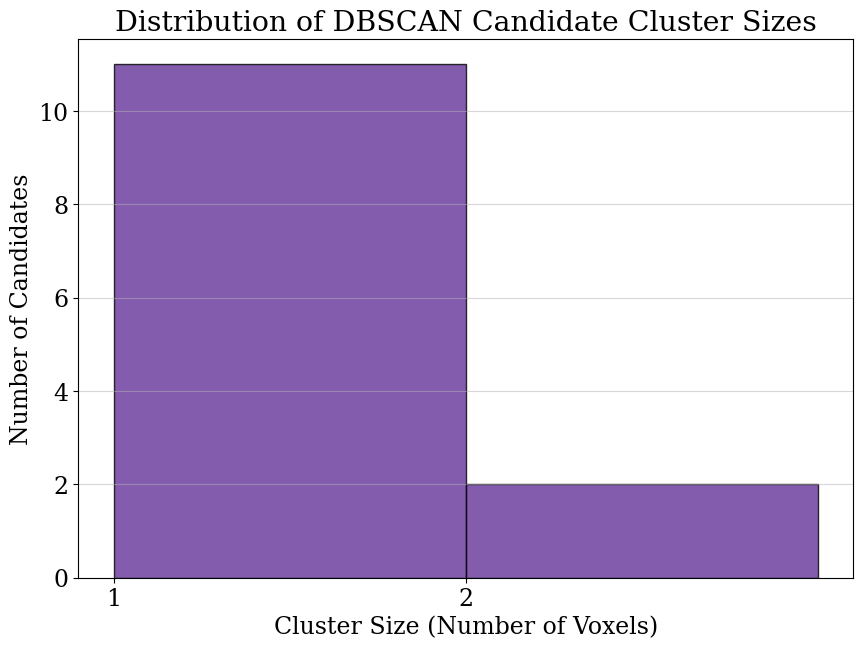

In [20]:
# --- DBSCAN Cluster Diagnostics ---

# This analysis uses the 'found_candidates_3d' list generated in Part 5
if 'found_candidates_3d' in locals() and len(found_candidates_3d) > 0:
    # Extract the size (in voxels) of each candidate cluster
    cluster_sizes = [cand['size_voxels'] for cand in found_candidates_3d]

    # --- Print Statistical Summary ---
    print("--- DBSCAN Cluster Size Report ---")
    print(f"Total number of candidates found: {len(cluster_sizes)}")
    print(f"Average cluster size: {np.mean(cluster_sizes):.2f} voxels")
    print(f"Standard deviation of cluster sizes: {np.std(cluster_sizes):.2f} voxels")
    print(f"Minimum cluster size: {np.min(cluster_sizes)} voxels")
    print(f"Maximum cluster size: {np.max(cluster_sizes)} voxels")
    print("------------------------------------")

    # --- Plot a Histogram of Cluster Sizes ---
    plt.figure(figsize=(10, 7))
    plt.hist(cluster_sizes, bins=range(min(cluster_sizes), max(cluster_sizes) + 2), 
             color='rebeccapurple', edgecolor='black', alpha=0.8)
    plt.title('Distribution of DBSCAN Candidate Cluster Sizes')
    plt.xlabel('Cluster Size (Number of Voxels)')
    plt.ylabel('Number of Candidates')
    plt.grid(True, axis='y', alpha=0.5)
    # Set x-axis ticks to be integers
    plt.xticks(np.arange(min(cluster_sizes), max(cluster_sizes)+1, step=max(1, (max(cluster_sizes)-min(cluster_sizes))//10)))
    plt.show()

else:
    print("No candidates were found, so no cluster diagnostics to report.")

***
### Vetting Candidates After Detection

The discussion of Peak vs. Integrated SNR describes how we *characterize* a candidate *after* it's been found by DBSCAN. The process of **vetting** or filtering that candidate list is a separate, subsequent step that uses these characterizations.

A candidate that is exceptionally large (e.g., spanning 10 or more channels) is highly unlikely to be a real, single OHM signal and is more likely to be some form of RFI or an instrumental artifact.

The vetting process works like this:

1.  **Detection and Characterization**: The pipeline runs, and DBSCAN produces a list of candidates. For each candidate, we have a set of properties, including its **peak SNR**, its **integrated SNR**, and its **size in voxels**.
2.  **Applying Cuts**: We then apply a series of "cuts" to this list to reject non-physical candidates. This is where your example comes in. We could define a rule like:
    * `IF candidate.size_voxels > 10 THEN REJECT`
    * `IF candidate.integrated_snr / candidate.peak_snr > some_threshold THEN REJECT` (This can find oddly shaped signals)
3.  **Final Candidate List**: Only the candidates that pass all these vetting cuts are considered high-quality detections worthy of follow-up.


***


## Part 6: Performance and Validation

Now we evaluate the performance of our search by comparing the candidates found by DBSCAN against our `ground_truth` injections. This allows us to calculate key performance metrics.

-----

### Deconstructing the Search Performance Report

The search performance report provides a quantitative summary of the pipeline's effectiveness by comparing the candidates it finds to the "ground truth" of the injected signals. The report is split into two sections: **Measured Metrics**, which describe the direct results of the search, and **Validation Metrics**, which compare the results to statistical predictions.

-----

### Measured Metrics

These metrics are calculated *after* running the search and matching the found candidates to the ground truth injections.

  * **True Positives (TP)**: The number of real, injected signals that were successfully detected by the pipeline.
  * **False Positives (FP)**: The number of candidates that were incorrectly flagged as signals but correspond only to noise.
  * **False Negatives (FN)**: The number of real, injected signals that the pipeline *failed* to detect.

From these counts, we derive two key rates:

1.  **Completeness (or Recall/True Positive Rate)**: This tells us what fraction of the total real signals we actually found. A perfect pipeline has a completeness of 100%.

    $\text{Completeness} = \frac{\text{TP}}{\text{TP} + \text{FN}} = \frac{\text{Number of Signals Found}}{\text{Total Number of Injected Signals}}$

2.  **Purity (or Precision)**: This tells us what fraction of the candidates we found are actually real signals. A perfect pipeline has a purity of 100%.

    $\text{Purity} = \frac{\text{TP}}{\text{TP} + \text{FP}} = \frac{\text{Number of Real Detections}}{\text{Total Number of Detections}}$

-----

### Validation Metrics (Statistical Predictions)

These metrics are calculated from first principles to predict how the pipeline *should* behave. Comparing these predictions to the measured metrics is a critical step in validating the pipeline.

1.  **Predicted True Positives**: We calculate the theoretical Signal-to-Noise Ratio (SNR) for every single injected signal. The predicted number of true positives is simply the count of injected signals whose theoretical SNR is greater than our detection threshold ($\sigma_{thresh}$).

    $\text{Predicted TP} = \sum_{i=1}^{N_{\text{injected}}} [ \text{SNR}*{\text{theoretical}, i} \ge \sigma*{\text{thresh}} ]$
    <br>
    *(where the square brackets represent the Iverson bracket, which is 1 if the condition is true and 0 otherwise)*

2.  **Predicted False Positives**: For pure Gaussian noise, we can predict the number of noise peaks that will cross our threshold by pure chance. This is the product of the total number of independent locations we searched ($N_{\text{voxels}}$) and the probability of a single standard normal variable exceeding the threshold. This probability is given by the Gaussian survival function, often denoted $Q(x)$.

    $\text{Predicted FP} = N_{\text{voxels}} \times Q(\sigma_{\text{thresh}})$
    <br>
    where
    <br>
    $Q(x) = \frac{1}{\sqrt{2\pi}} \int_x^\infty e^{-t^2/2} dt$

3.  **Predicted Purity**: Using the two predictions above, we can calculate a theoretical purity for our search. A close match between the measured and predicted purity gives us high confidence that the matched filter and noise statistics are well-understood.

    $ \text{Predicted Purity} = \frac{\text{Predicted TP}}{\text{Predicted TP} + \text{Predicted FP}} $

--- Step 1: Measuring final SNRs from the snr_cube ---
Validating the SNR for 200 ground truth injections...


Checking Ground Truth Injections:   0%|          | 0/200 [00:00<?, ?it/s]


--- Step 2: Calculating theoretical SNR for each injection ---


Calculating Theoretical SNRs:   0%|          | 0/200 [00:00<?, ?it/s]

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



--- Step 3: Identifying RFI-affected signals ---
  - Found 99 signals affected by RFI mask.


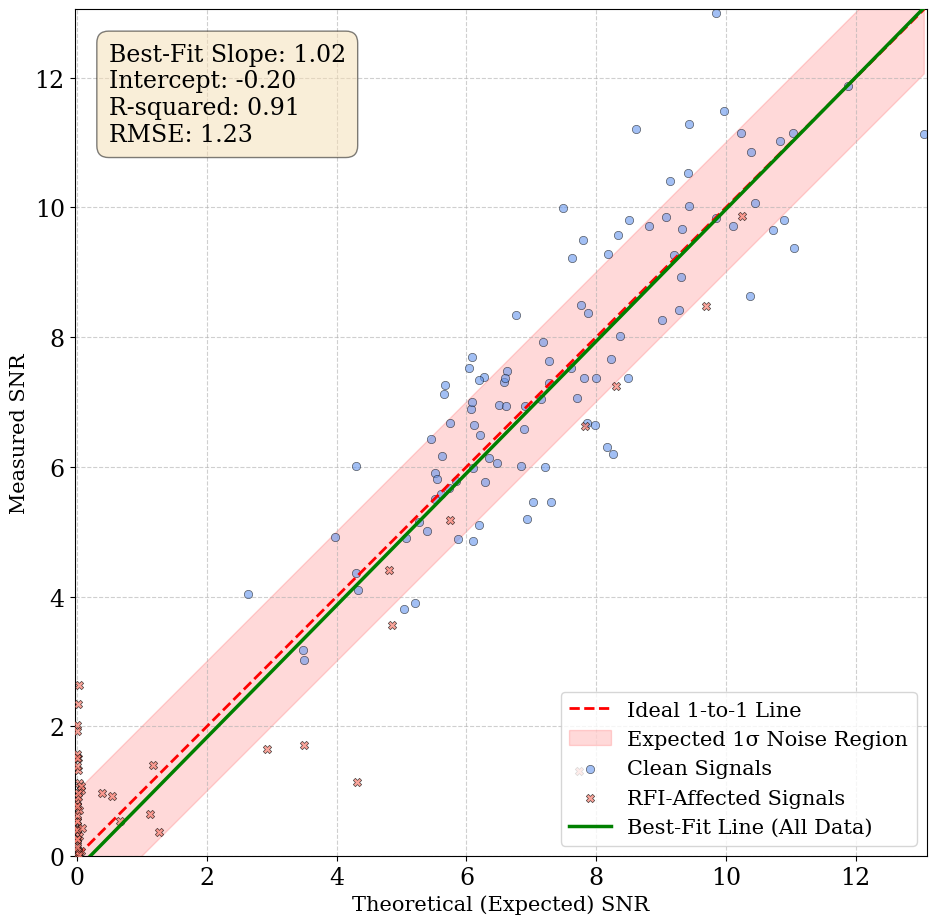


--- Higher Moment Analysis of SNR Residuals (Measured - Theoretical) ---
Skewness: -0.580
Kurtosis: 2.725



In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm.auto import tqdm
N_pix_x = 64
# --- 1. Calculate Measured SNRs ---
# This is the "ground truth" result from the final pipeline. We use the
# validation function to cleanly extract the SNR for each injected maser.
print("--- Step 1: Measuring final SNRs from the snr_cube ---")
# The validation function returns a list in the same order as the ground_truth injections
truth_validation_list = ocf.validate_from_ground_truth(
    snr_cube=snr_cube_3d,
    ground_truth=ground_truth,
    freqs_mhz=FREQS_MHZ,
    N_pix_x=N_pix_x,
    threshold=5
)
measured_snrs = np.array([item['max_snr'] for item in truth_validation_list])


# --- 2. Calculate Theoretical SNRs from Scratch ---
# This replicates the robust theoretical model calculation.
print("\n--- Step 2: Calculating theoretical SNR for each injection ---")
theoretical_snrs = []
for g in tqdm(ground_truth['injections'], desc="Calculating Theoretical SNRs"):
    noiseless_spectrum = g.get('noiseless_profile')
    if noiseless_spectrum is None:
        theoretical_snrs.append(0)
        continue

    # Apply the same delay filter used in the main pipeline
    filtered_noiseless_signal = oss.apply_windowed_delay_filter(
        spectrum=noiseless_spectrum,
        weights=np.ones(N_CHANNELS),
        freqs_mhz=FREQS_MHZ,
        delay_cut_ns=DELAY_CUT_NS
    )

    # Find the correct template and noise value for this injection's frequency
    true_freq = oss.z_to_freq(g['z'])
    template_idx = np.argmin(np.abs(FREQS_MHZ - true_freq))
    template = template_bank_full[template_idx]['prof']
    # Assumes 'noise_spectrum' was the second return value from run_matched_filter_cube
    noise_sigma_for_this_channel = noise_spectrum[template_idx]
    
    # Calculate the theoretical SNR using the core matched filter function
    theoretical_snr = oss.run_matched_filter_direct(
        spectrum=filtered_noiseless_signal,
        template=template,
        weights=rfi_mask_boolean,
        noise_sigma=noise_sigma_for_this_channel
    )
    theoretical_snrs.append(theoretical_snr)

theoretical_snrs = np.array(theoretical_snrs)


# --- 3. Identify RFI-Affected Signals for Color-Coding ---
print("\n--- Step 3: Identifying RFI-affected signals ---")
is_rfi_affected = []
for g in ground_truth['injections']:
    noiseless_spectrum = g.get('noiseless_profile')
    if noiseless_spectrum is None:
        is_rfi_affected.append(False); continue
    
    power_before_rfi = np.sum(noiseless_spectrum**2)
    power_after_rfi = np.sum((noiseless_spectrum * rfi_mask_boolean)**2)
    rfi_loss_fraction = 1.0 - (power_after_rfi / power_before_rfi) if power_before_rfi > 0 else 0
    is_rfi_affected.append(rfi_loss_fraction > 0.01)

is_rfi_affected = np.array(is_rfi_affected)
print(f"  - Found {np.sum(is_rfi_affected)} signals affected by RFI mask.")

# Separate the data into two groups for plotting
clean_theoretical = theoretical_snrs[~is_rfi_affected]
clean_measured = measured_snrs[~is_rfi_affected]
rfi_theoretical = theoretical_snrs[is_rfi_affected]
rfi_measured = measured_snrs[is_rfi_affected]


# --- 4. Calculate Overall Diagnostic Statistics ---
lin_reg = stats.linregress(theoretical_snrs, measured_snrs)
slope, intercept, r_value = lin_reg.slope, lin_reg.intercept, lin_reg.rvalue
rmse = np.sqrt(np.mean((measured_snrs - theoretical_snrs)**2))
residuals = measured_snrs - theoretical_snrs
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)


# --- 5. Create the Color-Coded Scatter Plot ---
fig = plt.figure(figsize=(11, 11))
# (The plotting code from here is the same as your provided cell)
max_val = max(np.max(theoretical_snrs), np.max(measured_snrs))
ideal_line = np.array([0, max_val])
plt.plot(ideal_line, ideal_line, 'r--', lw=2, label="Ideal 1-to-1 Line", zorder=3)
plt.fill_between(ideal_line, ideal_line - 1, ideal_line + 1, color='red',
                 alpha=0.15, label="Expected 1σ Noise Region", zorder=1)

plt.scatter(clean_theoretical, clean_measured, alpha=0.6, edgecolors='k', linewidth=0.5,
            label="Clean Signals", zorder=2, c='cornflowerblue')
plt.scatter(rfi_theoretical, rfi_measured, alpha=0.7, edgecolors='k', linewidth=0.5,
            label="RFI-Affected Signals", zorder=4, c='salmon', marker='X')

fit_line_y = slope * ideal_line + intercept
plt.plot(ideal_line, fit_line_y, 'g-', lw=2.5, label="Best-Fit Line (All Data)", zorder=5)

stats_text = (f"Best-Fit Slope: {slope:.2f}\nIntercept: {intercept:.2f}\n"
              f"R-squared: {r_value**2:.2f}\nRMSE: {rmse:.2f}")
plt.text(0.04, 0.96, stats_text, transform=plt.gca().transAxes,
         fontsize=17, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.xlabel("Theoretical (Expected) SNR", fontsize=15)
plt.ylabel("Measured SNR", fontsize=15)
# plt.title("Diagnostic: Measured vs. Theoretical SNR for All Injections", fontsize=14)
plt.legend(loc='lower right', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.xlim(0, max_val)
plt.ylim(0, max_val)
fig.savefig('scatter_plot.jpeg', dpi=150)
plt.show()

# --- 6. Print and Explain Higher Moments ---
print("\n--- Higher Moment Analysis of SNR Residuals (Measured - Theoretical) ---")
print(f"Skewness: {skewness:.3f}")
print(f"Kurtosis: {kurtosis:.3f}\n")
# ... (rest of the explanatory print statements)

--- Step 1: Measuring final SNRs from the snr_cube ---
Validating the SNR for 200 ground truth injections...


Checking Ground Truth Injections:   0%|          | 0/200 [00:00<?, ?it/s]


--- Step 2: Calculating theoretical SNR for each injection ---


Calculating Theoretical SNRs:   0%|          | 0/200 [00:00<?, ?it/s]

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



--- Step 3: Identifying RFI-affected signals ---
  - Found 99 signals affected by RFI mask.


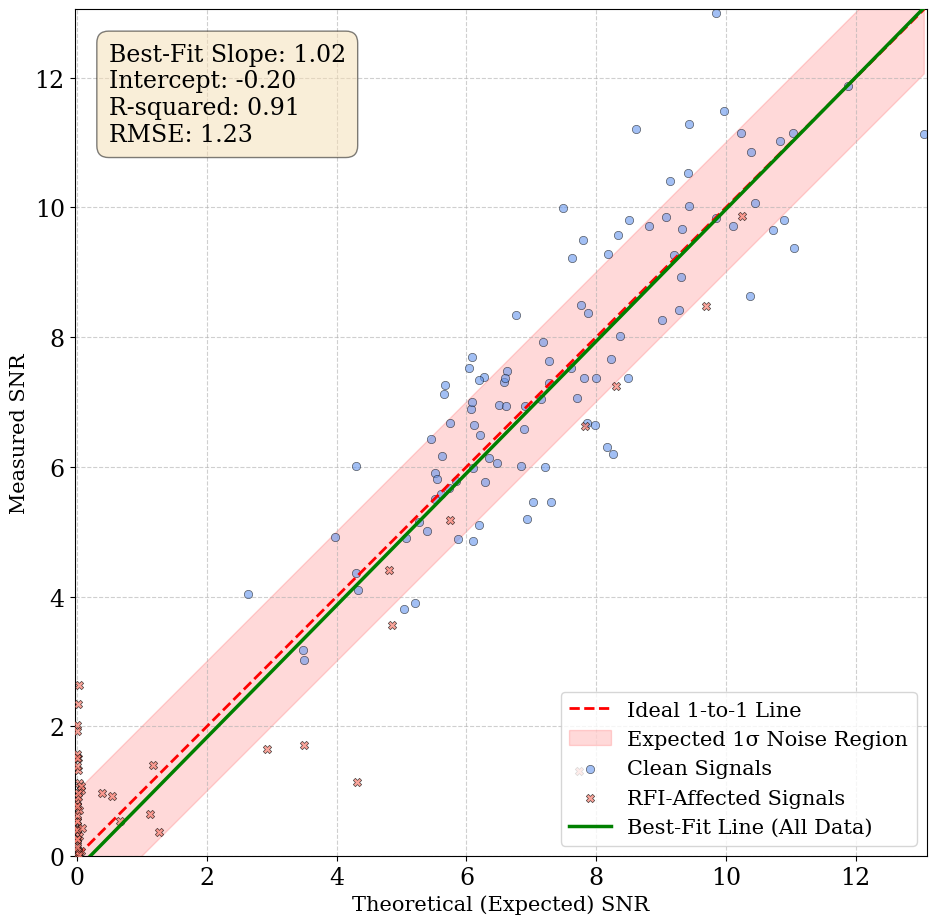


--- Higher Moment Analysis of SNR Residuals (Measured - Theoretical) ---
Skewness: -0.580
Kurtosis: 2.725



In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm.auto import tqdm
N_pix_x = 64
# --- 1. Calculate Measured SNRs ---
# This is the "ground truth" result from the final pipeline. We use the
# validation function to cleanly extract the SNR for each injected maser.
print("--- Step 1: Measuring final SNRs from the snr_cube ---")
# The validation function returns a list in the same order as the ground_truth injections
truth_validation_list = ocf.validate_from_ground_truth(
    snr_cube=snr_cube_3d,
    ground_truth=ground_truth,
    freqs_mhz=FREQS_MHZ,
    N_pix_x=N_pix_x,
    threshold=5
)
measured_snrs = np.array([item['max_snr'] for item in truth_validation_list])


# --- 2. Calculate Theoretical SNRs from Scratch ---
# This replicates the robust theoretical model calculation.
print("\n--- Step 2: Calculating theoretical SNR for each injection ---")
theoretical_snrs = []
for g in tqdm(ground_truth['injections'], desc="Calculating Theoretical SNRs"):
    noiseless_spectrum = g.get('noiseless_profile')
    if noiseless_spectrum is None:
        theoretical_snrs.append(0)
        continue

    # Apply the same delay filter used in the main pipeline
    filtered_noiseless_signal = oss.apply_windowed_delay_filter(
        spectrum=noiseless_spectrum,
        weights=np.ones(N_CHANNELS),
        freqs_mhz=FREQS_MHZ,
        delay_cut_ns=DELAY_CUT_NS
    )

    # Find the correct template and noise value for this injection's frequency
    true_freq = oss.z_to_freq(g['z'])
    template_idx = np.argmin(np.abs(FREQS_MHZ - true_freq))
    template = template_bank_full[template_idx]['prof']
    # Assumes 'noise_spectrum' was the second return value from run_matched_filter_cube
    noise_sigma_for_this_channel = noise_spectrum[template_idx]
    
    # Calculate the theoretical SNR using the core matched filter function
    theoretical_snr = oss.run_matched_filter_direct(
        spectrum=filtered_noiseless_signal,
        template=template,
        weights=rfi_mask_boolean,
        noise_sigma=noise_sigma_for_this_channel
    )
    theoretical_snrs.append(theoretical_snr)

theoretical_snrs = np.array(theoretical_snrs)


# --- 3. Identify RFI-Affected Signals for Color-Coding ---
print("\n--- Step 3: Identifying RFI-affected signals ---")
is_rfi_affected = []
for g in ground_truth['injections']:
    noiseless_spectrum = g.get('noiseless_profile')
    if noiseless_spectrum is None:
        is_rfi_affected.append(False); continue
    
    power_before_rfi = np.sum(noiseless_spectrum**2)
    power_after_rfi = np.sum((noiseless_spectrum * rfi_mask_boolean)**2)
    rfi_loss_fraction = 1.0 - (power_after_rfi / power_before_rfi) if power_before_rfi > 0 else 0
    is_rfi_affected.append(rfi_loss_fraction > 0.01)

is_rfi_affected = np.array(is_rfi_affected)
print(f"  - Found {np.sum(is_rfi_affected)} signals affected by RFI mask.")

# Separate the data into two groups for plotting
clean_theoretical = theoretical_snrs[~is_rfi_affected]
clean_measured = measured_snrs[~is_rfi_affected]
rfi_theoretical = theoretical_snrs[is_rfi_affected]
rfi_measured = measured_snrs[is_rfi_affected]


# --- 4. Calculate Overall Diagnostic Statistics ---
lin_reg = stats.linregress(theoretical_snrs, measured_snrs)
slope, intercept, r_value = lin_reg.slope, lin_reg.intercept, lin_reg.rvalue
rmse = np.sqrt(np.mean((measured_snrs - theoretical_snrs)**2))
residuals = measured_snrs - theoretical_snrs
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)


# --- 5. Create the Color-Coded Scatter Plot ---
fig = plt.figure(figsize=(11, 11))
# (The plotting code from here is the same as your provided cell)
max_val = max(np.max(theoretical_snrs), np.max(measured_snrs))
ideal_line = np.array([0, max_val])
plt.plot(ideal_line, ideal_line, 'r--', lw=2, label="Ideal 1-to-1 Line", zorder=3)
plt.fill_between(ideal_line, ideal_line - 1, ideal_line + 1, color='red',
                 alpha=0.15, label="Expected 1σ Noise Region", zorder=1)

plt.scatter(clean_theoretical, clean_measured, alpha=0.6, edgecolors='k', linewidth=0.5,
            label="Clean Signals", zorder=2, c='cornflowerblue')
plt.scatter(rfi_theoretical, rfi_measured, alpha=0.7, edgecolors='k', linewidth=0.5,
            label="RFI-Affected Signals", zorder=4, c='salmon', marker='X')

fit_line_y = slope * ideal_line + intercept
plt.plot(ideal_line, fit_line_y, 'g-', lw=2.5, label="Best-Fit Line (All Data)", zorder=5)

stats_text = (f"Best-Fit Slope: {slope:.2f}\nIntercept: {intercept:.2f}\n"
              f"R-squared: {r_value**2:.2f}\nRMSE: {rmse:.2f}")
plt.text(0.04, 0.96, stats_text, transform=plt.gca().transAxes,
         fontsize=17, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.xlabel("Theoretical (Expected) SNR", fontsize=15)
plt.ylabel("Measured SNR", fontsize=15)
# plt.title("Diagnostic: Measured vs. Theoretical SNR for All Injections", fontsize=14)
plt.legend(loc='lower right', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.xlim(0, max_val)
plt.ylim(0, max_val)
fig.savefig('scatter_plot.jpeg', dpi=150)
plt.show()

# --- 6. Print and Explain Higher Moments ---
print("\n--- Higher Moment Analysis of SNR Residuals (Measured - Theoretical) ---")
print(f"Skewness: {skewness:.3f}")
print(f"Kurtosis: {kurtosis:.3f}\n")
# ... (rest of the explanatory print statements)

In [40]:
theoretical_snrs_all = theoretical_snrs

### 6.3: Diagnostic Plot 3: Data and SNR Cube Histograms

This plot shows the distribution of values in our original data cube and the final SNR cube. It provides another essential sanity check:

1.  **Data Cube (Noise)**: Since our input data is dominated by Gaussian noise with σ=1, its histogram should look like a standard normal distribution centered at 0.
2.  **SNR Cube (Noise)**: The SNR cube, in regions without signals, represents the output of the matched filter applied to pure noise. The distribution of these noise values should also be a Gaussian centered at 0, but its standard deviation will depend on the filter properties. For an optimal filter, we expect σ≈1.

A significant deviation from a Gaussian distribution in the SNR cube's noise could indicate a problem with the matched filter implementation.

--- Preparing voxel data for distribution plots ---


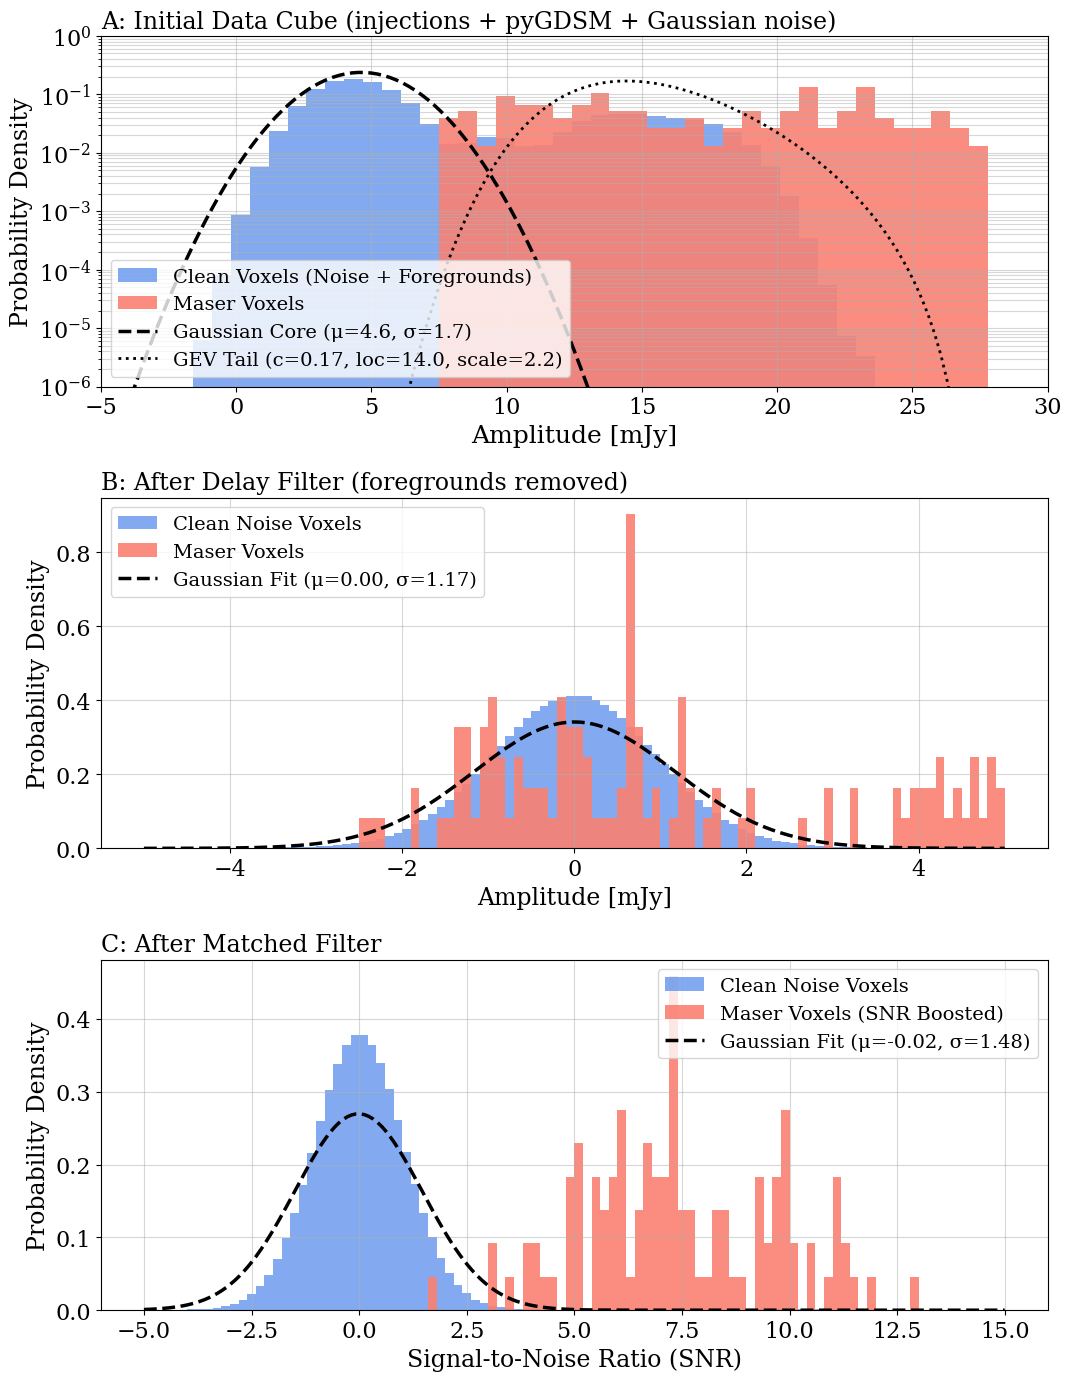

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, genextreme

# --- 1. Prepare Data for Analysis ---
print("--- Preparing voxel data for distribution plots ---")
# (Data preparation logic remains the same)
injection_mask = np.zeros_like(data_cube, dtype=bool)
for g in ground_truth['injections']:
    pixel_idx, true_z = g['pixel_index'], g['z']
    freq_idx = np.argmin(np.abs(FREQS_MHZ - oss.z_to_freq(true_z)))
    injection_mask[pixel_idx, freq_idx] = True
clean_noise_mask = (~injection_mask) & rfi_mask_boolean
maser_mask = injection_mask & rfi_mask_boolean
data_cube_masers = data_cube[maser_mask] #data_cube[injection_mask]
data_cube_clean_noise = data_cube[clean_noise_mask]
delay_filtered_masers = delay_filtered_cube[injection_mask]
delay_filtered_clean_noise = delay_filtered_cube[clean_noise_mask]
snr_cube_masers = snr_cube_3d[maser_mask] #nr_cube_3d[injection_mask]
snr_cube_clean_noise = snr_cube_3d[clean_noise_mask]

# --- 2. Create the Figure ---
plt.rcParams.update({'font.size': 16, 'font.family': 'serif'})
fig, axes = plt.subplots(3, 1, figsize=(11, 15))
# fig.suptitle("Distribution of Voxel Values at Each Pipeline Stage", fontsize=24, y=0.96)


# --- Panel A: Initial Data Cube (with final robust fit) ---
axes[0].set_yscale('log')
axes[0].hist(data_cube_clean_noise, bins=100, range=(-10, 60), density=True, label='Clean Voxels (Noise + Foregrounds)', color='cornflowerblue', alpha=0.8)
axes[0].hist(data_cube_masers, bins=100, range=(-10, 60), density=True, label='Maser Voxels', color='salmon', alpha=0.9)

# a) Fit a Gaussian to the CORE of the distribution (< 10 Jy)
core_data = data_cube_clean_noise[data_cube_clean_noise < 10]
mu_g, std_g = norm.fit(core_data)
x_fit = np.linspace(-10, 60, 300)
gaussian_fit_pdf = norm.pdf(x_fit, mu_g, std_g)
axes[0].plot(x_fit, gaussian_fit_pdf, 'k--', lw=2.5, label=f'Gaussian Core (μ={mu_g:.1f}, σ={std_g:.1f})')

# b) Fit a GEV distribution to the TAIL of the distribution
tail_data = data_cube_clean_noise[data_cube_clean_noise > 10]
c, loc, scale = genextreme.fit(tail_data)
gev_fit_pdf = genextreme.pdf(x_fit, c, loc, scale)
axes[0].plot(x_fit, gev_fit_pdf, 'g-', lw=2, color='k', linestyle='dotted', label=f'GEV Tail (c={c:.2f}, loc={loc:.1f}, scale={scale:.1f})')

axes[0].set_title("A: Initial Data Cube (injections + pyGDSM + Gaussian noise)", loc='left', fontsize=17)
axes[0].set_xlabel("Amplitude [mJy]", fontsize=18)
axes[0].set_ylabel("Probability Density", fontsize=17)
axes[0].set_ylim(bottom=1e-6, top=1)
axes[0].set_xlim(-5, 30)
axes[0].legend(fontsize=14)
axes[0].grid(True, alpha=0.5, which='both')


# --- Panel B: Delay Filtered Cube ---
# (This panel's logic remains the same)
axes[1].hist(delay_filtered_clean_noise, bins=100, range=(-5, 5), density=True, label='Clean Noise Voxels', color='cornflowerblue', alpha=0.8)
axes[1].hist(delay_filtered_masers, bins=100, range=(-5, 5), density=True, label='Maser Voxels', color='salmon', alpha=0.9)
mu, std = norm.fit(delay_filtered_clean_noise)
x_b = np.linspace(-5, 5, 200)
axes[1].plot(x_b, norm.pdf(x_b, mu, std), 'k--', lw=2.5, label=f'Gaussian Fit (μ={mu:.2f}, σ={std:.2f})')
axes[1].set_title("B: After Delay Filter (foregrounds removed)", loc='left', fontsize=17)
axes[1].set_xlabel("Amplitude [mJy]", fontsize=17)
axes[1].set_ylabel("Probability Density", fontsize=17)
axes[1].legend(fontsize=14, loc='upper left')
axes[1].grid(True, alpha=0.5)


# --- Panel C: Matched Filter SNR Cube ---
# (This panel's logic remains the same)
axes[2].hist(snr_cube_clean_noise, bins=100, range=(-5, 15), density=True, label='Clean Noise Voxels', color='cornflowerblue', alpha=0.8)
axes[2].hist(snr_cube_masers, bins=100, range=(-5, 15), density=True, label='Maser Voxels (SNR Boosted)', color='salmon', alpha=0.9)
mu, std = norm.fit(snr_cube_clean_noise)
x_c = np.linspace(-5, 15, 200)
axes[2].plot(x_c, norm.pdf(x_c, mu, std), 'k--', lw=2.5, label=f'Gaussian Fit (μ={mu:.2f}, σ={std:.2f})')
axes[2].set_title("C: After Matched Filter", loc='left', fontsize=17)
axes[2].set_xlabel("Signal-to-Noise Ratio (SNR)", fontsize=17)
axes[2].set_ylabel("Probability Density", fontsize=17)
# axes[2].set_yscale('log')
axes[2].legend(fontsize=14, loc='upper right')
axes[2].grid(True, alpha=0.5, which='both')


# --- Final Touches ---
plt.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig('histogram_pipeline.jpeg', dpi=150)
plt.show()

--- Preparing data for 3D SNR cube visualization ---


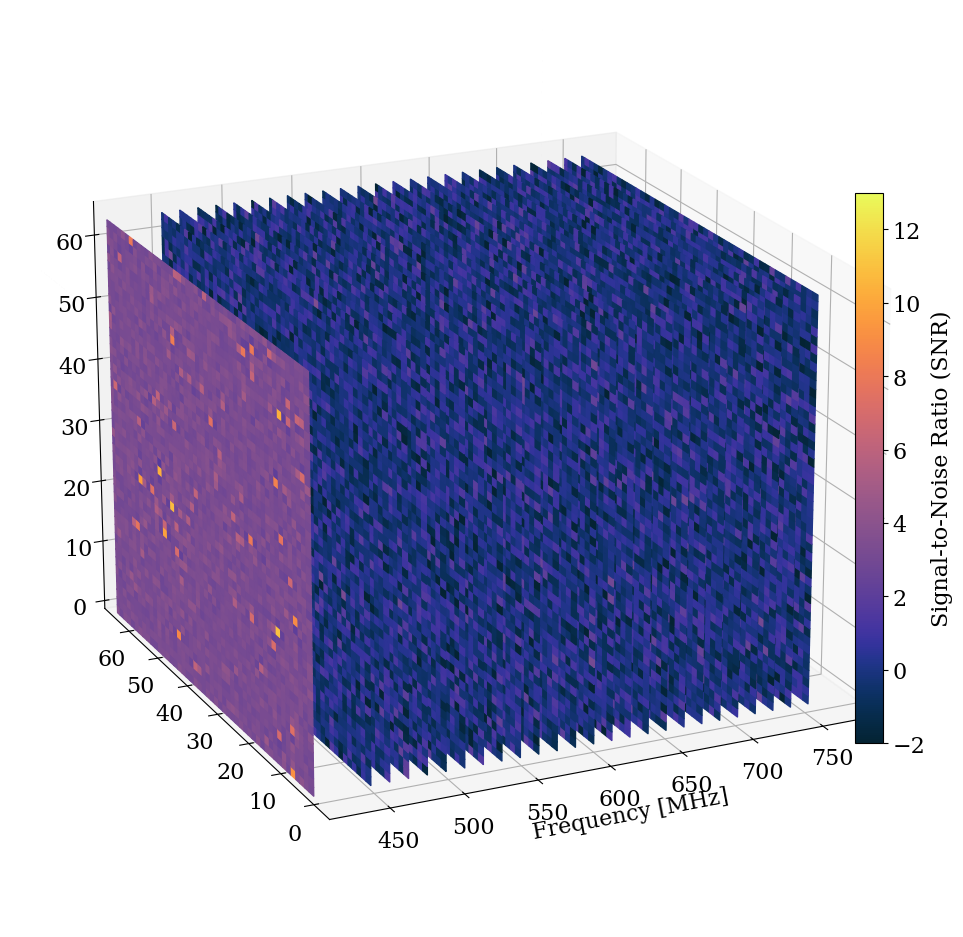

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import zoom

# --- 1. Prepare Data for Analysis ---
print("--- Preparing data for 3D SNR cube visualization ---")

edge_cut = 25
snr_cube_3d_truncated = snr_cube_3d[:, edge_cut:-edge_cut]
freqs_truncated = FREQS_MHZ[edge_cut:-edge_cut]
n_channels_truncated = len(freqs_truncated)
snr_cube_3d_reshaped = snr_cube_3d_truncated.reshape(GRID_SHAPE[0], GRID_SHAPE[1], n_channels_truncated)
max_snr_projection = np.max(snr_cube_3d_reshaped, axis=2)
snr_std_per_channel = np.std(snr_cube_3d_truncated, axis=0)

# --- 2. User-Adjustable Plotting Parameters ---
# This factor controls the length of the 3D cube (e.g., 0.8 = 80% of the axis width)
stretch_factor = .8
# This factor controls the left-right position of the cube (0=left, 0.5=center, 1=right)
shift_factor = .5
num_slices = 25

# --- 3. Create the Figure ---
plt.rcParams.update({'font.size': 16, 'font.family': 'serif'})
fig = plt.figure(figsize=(15, 15))
gs = fig.add_gridspec(3, 1, hspace=0)

# --- Panel A: Tilted 3D Stacked-Slice Visualization ---
ax1 = fig.add_subplot(gs[0:2, 0], projection='3d')
# ax1.set_title("SNR Cube Visualization (Edge Channels Removed)", fontsize=22, pad=0)

cmap = cmocean.cm.thermal
norm = plt.Normalize(vmin=-2, vmax=np.max(max_snr_projection))

# Determine the frequency range and position for the stretched cube
full_freq_range = freqs_truncated.max() - freqs_truncated.min()
cube_length = full_freq_range * stretch_factor
available_shift_space = full_freq_range - cube_length
slice_start_freq = freqs_truncated.min() + (available_shift_space * shift_factor)
slice_end_freq = slice_start_freq + cube_length

# --- Plot the 2D Maximum Projection ---
projection_pos = slice_start_freq - (0.1 * full_freq_range)
smoothed_projection = zoom(max_snr_projection, 3)
Y_proj, Z_proj = np.meshgrid(np.linspace(0, GRID_SHAPE[0], smoothed_projection.shape[0]),
                             np.linspace(0, GRID_SHAPE[1], smoothed_projection.shape[1]))
ax1.plot_surface(np.full_like(Y_proj, projection_pos), Y_proj, Z_proj,
                 facecolors=cmap(norm(smoothed_projection)), rstride=4, cstride=4, shade=False)
ax1.text(projection_pos, -5, GRID_SHAPE[1] + 5, "Max Projection", color='k', ha='center')

# --- Plot the Angled Slices ---
slice_plot_positions = np.linspace(slice_start_freq, slice_end_freq, num_slices)
slice_data_indices = np.linspace(0, n_channels_truncated - 1, num_slices, dtype=int)
for i, plot_pos in enumerate(slice_plot_positions):
    data_idx = slice_data_indices[i]
    image_slice = snr_cube_3d_reshaped[:, :, data_idx]
    smoothed_slice = zoom(image_slice, 3)
    Y, Z = np.meshgrid(np.linspace(0, GRID_SHAPE[0], smoothed_slice.shape[0]),
                       np.linspace(0, GRID_SHAPE[1], smoothed_slice.shape[1]))
    ax1.plot_surface(np.full_like(Y, plot_pos), Y, Z,
                     facecolors=cmap(norm(smoothed_slice)),
                     rstride=4, cstride=4, shade=False)

# --- Finalize 3D Panel ---
# ax1.set_axis_off()
ax1.view_init(elev=20, azim=-115)
ax1.set_xlim(freqs_truncated.min(), freqs_truncated.max())
ax1.set_xlabel('Frequency [MHz]')

# --- Panel B: Summary Spectrum ---
# ax2 = fig.add_subplot(gs[2, 0])
# ax2.set_title("SNR Standard Deviation Across Sky", fontsize=20)
# ax2.plot(freqs_truncated, snr_std_per_channel, color='C1', lw=2.5)
# ax2.set_xlabel("Frequency [MHz]", fontsize=18)
# ax2.set_ylabel("Std. Dev. of SNR", fontsize=18)
# ax2.grid(True, linestyle='--', alpha=0.6)
# ax2.set_xlim(freqs_truncated.min(), freqs_truncated.max())
# ax2.fill_between(freqs_truncated, 1.0, snr_std_per_channel, where=snr_std_per_channel > 1.2,
#                  color='C1', alpha=0.3, label='Channels with Signal')
# ax2.axhline(1.0, color='k', linestyle='--', label='Expected Noise Level (σ=1)')
# ax2.legend(fontsize=14)

# --- Final Touches ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax1, shrink=0.6, aspect=20, pad=-0.05)
cbar.set_label('Signal-to-Noise Ratio (SNR)', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('SNR_cube.jpeg', dpi=150)
plt.show()

### Part 7: ROC Curve Performance Comparison

A **Receiver Operating Characteristic (ROC)** curve is a powerful tool for evaluating the performance of a detection algorithm. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various threshold settings.

  * **True Positive Rate (TPR)**, or "Completeness": The fraction of real signals that are correctly identified. (TP / Total Real Signals)
  * **False Positive Rate (FPR)**: The fraction of non-signals (i.e., noise) that are incorrectly flagged as detections. (FP / Total Non-Signals)

A perfect classifier would have a point in the top-left corner (TPR=1, FPR=0), while a random guess would fall along the diagonal line (TPR=FPR). The further a curve bows towards the top-left, the better the algorithm's performance.

In this cell, we will compare four different search methods:

1.  **Simple Threshold Search**: Our baseline, flagging any voxel in the raw data cube that exceeds a threshold.
2.  **Gaussian Template Matched Filter**: A search using a simple Gaussian profile as a template. This tests the benefit of matched filtering in its most basic form.
3.  **Single OHM Template Matched Filter**: An intermediate step where we use a matched filter, but with only *one* "typical" (and more complex) OHM template.
4.  **Full OHM Template Bank**: The complete pipeline, which uses a bank of templates tailored to different redshifts.

We expect to see a clear hierarchy of performance, with the full template bank being the best. We also add annotated markers at integer sigma levels to show exactly where our chosen operating points lie on these curves.

In [86]:
gauss_template = otg.generate_gaussian_template(width=11, sigma_fraction=.1)

In [29]:
# --- ROC Curve Generation ---
print("--- Generating Data for ROC Curves (Standardized Comparison) ---")

# --- 1. Define Common Parameters & Ground Truth Mask ---
roc_thresholds = np.linspace(0, 15, 50)
n_total_positives = N_INJECTIONS
injection_mask = np.zeros_like(delay_filtered_cube, dtype=bool)
for g in ground_truth['injections']:
    pixel_idx, true_z = g['pixel_index'], g['z']
    freq_idx = np.argmin(np.abs(FREQS_MHZ - oss.z_to_freq(true_z)))
    injection_mask[pixel_idx, freq_idx] = True
noise_mask = ~injection_mask
n_noise_voxels = np.sum(noise_mask)
noise_spectrum = np.std(delay_filtered_cube[cold_pixel_indices, :], axis=0)


# --- Method 1: Simple Threshold (Baseline) ---
print("\n1/5: Generating Simple Threshold SNR Cube...")
snr_cube_simple = delay_filtered_cube / noise_spectrum
tpr_simple, fpr_simple = [], []
# (Loop for simple threshold remains the same)
for thresh in roc_thresholds:
    tp = np.sum(snr_cube_simple[injection_mask] > thresh)
    fp = np.sum(snr_cube_simple[noise_mask] > thresh)
    tpr_simple.append(tp / n_total_positives)
    fpr_simple.append(fp / n_noise_voxels)

# --- Method 2: Boxcar Template Matched Filter (NEW) ---
print("\n2/5: Building Boxcar Template Bank...")
template_bank_boxcar = otg.create_boxcar_template_bank(
    native_freq_grid=FREQS_MHZ, delay_cut_ns=DELAY_CUT_NS, template_width=3 # adjust this
)
print("Generating Boxcar Template SNR Cube...")
snr_cube_boxcar, _ = oss.run_matched_filter_cube(
    data_cube=delay_filtered_cube, template_bank_full=template_bank_boxcar, weights=rfi_mask_boolean
)
tpr_boxcar, fpr_boxcar = [], []
for thresh in tqdm(roc_thresholds, desc="Boxcar Template"):
    tp = np.sum(snr_cube_boxcar[injection_mask] > thresh)
    fp = np.sum(snr_cube_boxcar[noise_mask] > thresh)
    tpr_boxcar.append(tp / n_total_positives)
    fpr_boxcar.append(fp / n_noise_voxels)


# --- Method 3: Gaussian Template Matched Filter ---
print("\n3/5: Building Gaussian Template Bank...")
template_bank_gauss = otg.create_gaussian_template_bank(
    native_freq_grid=FREQS_MHZ, delay_cut_ns=DELAY_CUT_NS
)
print("Generating Gaussian Template SNR Cube...")
snr_cube_gauss, _ = oss.run_matched_filter_cube(
    data_cube=delay_filtered_cube, template_bank_full=template_bank_gauss, weights=rfi_mask_boolean
)
tpr_gauss, fpr_gauss = [], []
# (Loop for Gaussian template remains the same)
for thresh in roc_thresholds:
    tp = np.sum(snr_cube_gauss[injection_mask] > thresh)
    fp = np.sum(snr_cube_gauss[noise_mask] > thresh)
    tpr_gauss.append(tp / n_total_positives)
    fpr_gauss.append(fp / n_noise_voxels)

# --- Method 4: Single OHM Template ---
print("\n4/5: Building Single OHM Template Bank...")
template_bank_single_ohm = otg.create_single_ohm_template_bank(
    intrinsic_template_v=intrinsic_template_v, vel_axis_kms=VEL_AXIS,
    native_freq_grid=FREQS_MHZ, delay_cut_ns=DELAY_CUT_NS
)
print("Generating Single OHM Template SNR Cube...")
snr_cube_single, _ = oss.run_matched_filter_cube(
    data_cube=delay_filtered_cube, template_bank_full=template_bank_single_ohm, weights=rfi_mask_boolean
)
tpr_single, fpr_single = [], []
# (Loop for Single OHM template remains the same)
for thresh in roc_thresholds:
    tp = np.sum(snr_cube_single[injection_mask] > thresh)
    fp = np.sum(snr_cube_single[noise_mask] > thresh)
    tpr_single.append(tp / n_total_positives)
    fpr_single.append(fp / n_noise_voxels)

# --- Method 5: Full, Redshift-Dependent Template Bank ---
print("\n5/5: Calculating stats for Full Template Bank...")
# We just reuse the snr_cube_3d result from the main analysis cell.
tpr_bank, fpr_bank = [], []
# (Loop for Full Bank remains the same)
for thresh in roc_thresholds:
    tp = np.sum(snr_cube_3d[injection_mask] > thresh)
    fp = np.sum(snr_cube_3d[noise_mask] > thresh)
    tpr_bank.append(tp / n_total_positives)
    fpr_bank.append(fp / n_noise_voxels)

--- Generating Data for ROC Curves (Standardized Comparison) ---

1/5: Generating Simple Threshold SNR Cube...

2/5: Building Boxcar Template Bank...
Building aligned boxcar template bank...


Filtering Boxcar Templates:   0%|          | 0/1024 [00:00<?, ?it/s]

Generating Boxcar Template SNR Cube...
  - Estimating noise with robust MAD estimator...


Applying Matched Filter to each Frequency Bin:   0%|          | 0/4096 [00:00<?, ?it/s]

Boxcar Template:   0%|          | 0/50 [00:00<?, ?it/s]

...

Generating Gaussian Template SNR Cube...
  - Estimating noise with robust MAD estimator...


Applying Matched Filter to each Frequency Bin:   0%|          | 0/4096 [00:00<?, ?it/s]


4/5: Building Single OHM Template Bank...
Building single OHM template bank based on z=2.0 profile...
Generating Single OHM Template SNR Cube...
  - Estimating noise with robust MAD estimator...


Applying Matched Filter to each Frequency Bin:   0%|          | 0/4096 [00:00<?, ?it/s]


5/5: Calculating stats for Full Template Bank...


In [33]:
# --- Object-Based ROC Curve Generation with Final Vetting ---
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DBSCAN_EPS = 11
DBSCAN_MIN_SAMPLES = 1

print("--- Generating Data for Object-Based ROC Curve ---")
print("Warning: This may take a significant amount of time.")

# --- 1. Setup ---
roc_thresholds_intensive = np.linspace(4.0, 12.0, 30)
n_total_negatives = N_PIXELS
# theoretical_snrs = np.array(theoretical_snrs_all)

# --- 2. Define "TRULY Detectable" Positives ---
lowest_threshold = roc_thresholds_intensive.min()
n_truly_detectable = 0
# Create a map for quick lookup of an injection's global index
injection_map = {id(g): i for i, g in enumerate(ground_truth['injections'])}
for i, g in enumerate(ground_truth['injections']):
    is_bright_enough = theoretical_snrs[i] > lowest_threshold
    true_freq = oss.z_to_freq(g['z'])
    freq_idx = np.argmin(np.abs(FREQS_MHZ - true_freq))
    is_in_clean_channel = rfi_mask_boolean[freq_idx]
    if is_bright_enough and is_in_clean_channel:
        n_truly_detectable += 1
print(f"\nNormalizing TPR against {n_truly_detectable} truly detectable injections.")

# --- 3. Prepare Cubes ---
all_cubes_to_test = [
    ("Simple Threshold", snr_cube_simple),
    ("Boxcar Template", snr_cube_boxcar),
    ("Gaussian Template", snr_cube_gauss),
    ("Single OHM Template", snr_cube_single),
    ("Full OHM Template Bank", snr_cube_3d)
]
all_roc_results = {}

# --- 4. Main Loop ---
for name, cube in all_cubes_to_test:
    tpr_list, fpr_list = [], []
    print(f"\nProcessing method: {name}")
    snr_cube_3d_reshaped = cube.reshape(GRID_SHAPE[0], GRID_SHAPE[1], N_CHANNELS)

    for thresh in tqdm(roc_thresholds_intensive, desc=f"Testing Thresholds for {name}"):
        found_candidates = ocf.find_candidates_3d_dbscan(
            snr_cube=snr_cube_3d_reshaped, snr_threshold=thresh,
            eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES, freqs_mhz=FREQS_MHZ
        )
        
        n_tp = 0
        n_fp = 0
        if len(found_candidates) > 0:
            vetted_candidates = []
            for cand in found_candidates:
                centroid_freq = cand['centroid_z_freq'] # Use correct key
                freq_idx = np.argmin(np.abs(FREQS_MHZ - centroid_freq))
                if rfi_mask_boolean[freq_idx]:
                    vetted_candidates.append(cand)

            matched_results = ocf.match_candidates_to_truth_3d(
                candidates=vetted_candidates, ground_truth=ground_truth,
                grid_shape=GRID_SHAPE, freqs_mhz=FREQS_MHZ
            )
            
            # --- THIS IS THE NEW VETTING STEP ---
            # Double-check each true positive to ensure it's not a noise spike.
            vetted_true_positives = []
            for match in matched_results['true_positives']:
                candidate_snr = match['cand']['peak_snr']
                # Find the theoretical SNR for the matched injection
                injection_idx = injection_map[id(match['inj'])]
                theoretical_snr = theoretical_snrs[injection_idx]
                
                # A true detection's SNR should be close to its theoretical value.
                # If it's more than 3-sigma higher, it's likely a noise spike.
                if (candidate_snr - theoretical_snr) < 3.0:
                    vetted_true_positives.append(match)
            # ------------------------------------

            n_tp = len(vetted_true_positives)
            n_fp = len(matched_results['false_positives'])
            
        tpr = n_tp / n_truly_detectable if n_truly_detectable > 0 else 0
        fpr = n_fp / n_total_negatives if n_total_negatives > 0 else 0
        tpr_list.append(tpr)
        fpr_list.append(fpr)
        
    all_roc_results[name] = {'tpr': np.array(tpr_list), 'fpr': np.array(fpr_list)}

--- Generating Data for Object-Based ROC Curve ---

Normalizing TPR against 104 truly detectable injections.

Processing method: Simple Threshold


Testing Thresholds for Simple Threshold:   0%|          | 0/30 [00:00<?, ?it/s]


Processing method: Boxcar Template


Testing Thresholds for Boxcar Template:   0%|          | 0/30 [00:00<?, ?it/s]


Processing method: Gaussian Template


Testing Thresholds for Gaussian Template:   0%|          | 0/30 [00:00<?, ?it/s]


Processing method: Single OHM Template


Testing Thresholds for Single OHM Template:   0%|          | 0/30 [00:00<?, ?it/s]


Processing method: Full OHM Template Bank


Testing Thresholds for Full OHM Template Bank:   0%|          | 0/30 [00:00<?, ?it/s]

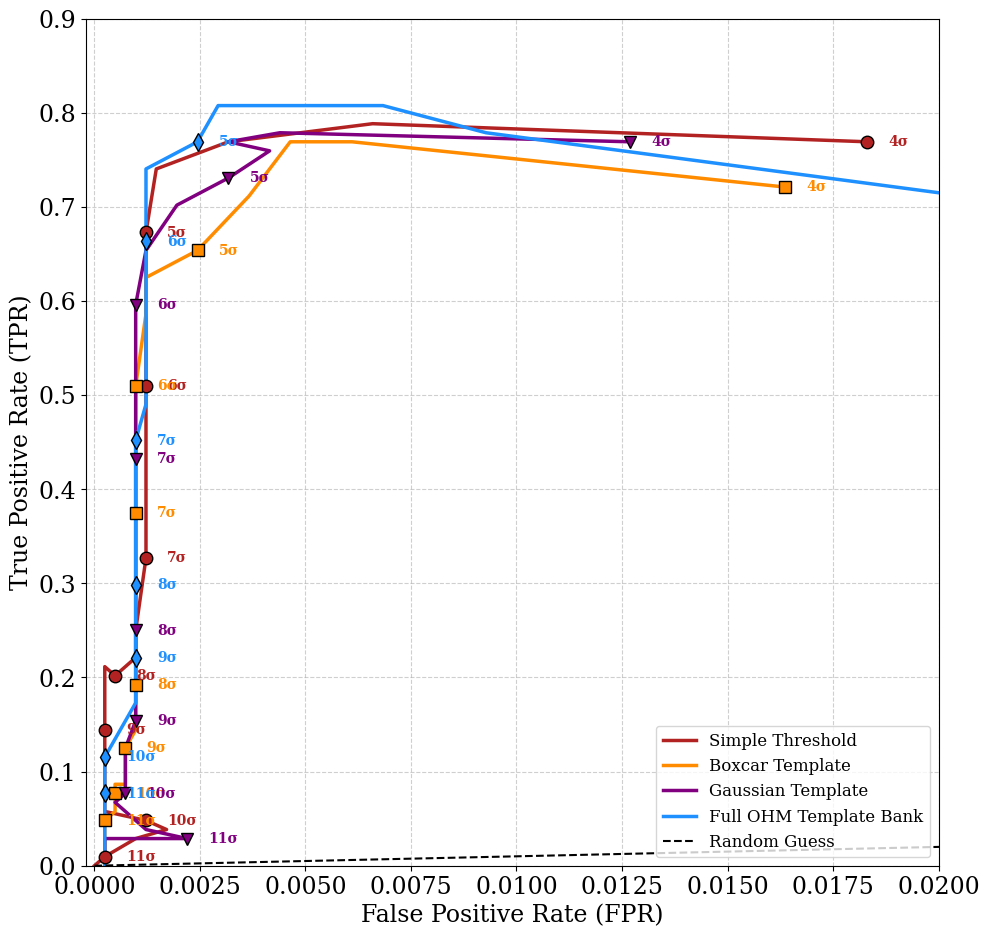

In [34]:
# --- Final ROC Plotting ---
fig = plt.figure(figsize=(11, 11))
ax = plt.gca()

# --- Define the visible area of the plot FIRST ---
xlim = (-0.0002, 0.02)
ylim = (0, .9) # Adjusted y-limit to better see the curves
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# --- Data for plotting ---
# Add the new "Boxcar Template" to this list for plotting
all_curves_data = [
    ("Simple Threshold", all_roc_results['Simple Threshold'], 'firebrick', 'o'),
    ("Boxcar Template", all_roc_results['Boxcar Template'], 'darkorange', 's'), # NEW
    ("Gaussian Template", all_roc_results['Gaussian Template'], 'purple', 'v'),
    # ("Single OHM Template", all_roc_results['Single OHM Template'], 'darkorange', 's'),
    ("Full OHM Template Bank", all_roc_results['Full OHM Template Bank'], 'dodgerblue', 'd')
]

# --- Main Plotting Loop with Robust Truncation Logic ---
for label, results, color, marker in all_curves_data:
    # Reverse the arrays so they run from (0,0) towards (1,1)
    fpr_vals = results['fpr'][::-1]
    tpr_vals = results['tpr'][::-1]

    # Find the maximum TPR value achieved by this curve
    max_tpr = np.max(tpr_vals)
    
    # Find the index of the FIRST time this maximum TPR is reached
    knee_idx_list = np.where(tpr_vals >= max_tpr * 0.999)[0]
    
    # if len(knee_idx_list) > 0:
    #     knee_idx = knee_idx_list[0]
    #     # Plot the data only up to and including this "knee"
    #     ax.plot(fpr_vals[:knee_idx+1], tpr_vals[:knee_idx+1], label=label, color=color, lw=2.5)
    # else:
    #     # If for some reason no point reaches the max, plot the whole thing
    ax.plot(fpr_vals, tpr_vals, label=label, color=color, lw=2.5)


# Plot the random guess line
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# --- Add annotated sigma markers with boundary checks ---
sigma_markers = range(4, 12) # From 5 to 11 sigma
reversed_thresholds = roc_thresholds_intensive[::-1]

for sigma in sigma_markers:
    # Find the index in our REVERSED threshold array closest to the target sigma
    idx = (np.abs(reversed_thresholds - sigma)).argmin()
    
    for label, results, color, marker in all_curves_data:
        # Get the data points from the REVERSED arrays
        fpr_at_sigma = results['fpr'][::-1][idx]
        tpr_at_sigma = results['tpr'][::-1][idx]
        
        # Only plot the marker and text if it falls within our predefined x and y limits.
        if xlim[0] <= fpr_at_sigma <= xlim[1] and ylim[0] <= tpr_at_sigma <= ylim[1]:
            ax.plot(fpr_at_sigma, tpr_at_sigma, marker, color=color, markersize=9, markeredgecolor='black')
            ax.text(fpr_at_sigma + 0.0005, tpr_at_sigma, f'{int(sigma)}σ',
                    color=color, fontsize=10, ha='left', va='center', weight='bold')

# --- Final plot settings ---
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
# ax.set_title('Object-Based ROC Curve Comparison (Truncated at Max TPR)')
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, which="both", ls="--", alpha=0.6)
fig.savefig('ROC_plot_FFT_high_amp_smaller_vetted.jpeg', dpi=150)
plt.show()

---
### A Figure of Merit: The ROC Curve from Radar to Radio Astronomy

To truly understand how well our search pipeline performs, we need a "figure of merit"—a single, quantitative measure of its effectiveness. While metrics like **completeness** and **purity** are informative for a *single* threshold, they don't capture the full picture of the trade-offs involved in a detection algorithm. The **Receiver Operating Characteristic (ROC)** curve provides this complete picture.

#### From Radar Engineering to the Cosmos 📡

The ROC curve was originally developed during World War II for operators of **radar** signal receivers. The fundamental problem they faced is identical to ours in radio astronomy: how do you set your detection threshold to reliably distinguish a faint, real signal (an enemy aircraft) from the ever-present background noise (atmospheric static, instrument noise)?

* Set the threshold **too low**, and you get a high **completeness** (you find every real aircraft), but you are flooded with **false positives** (you mistake noise for an aircraft), making the system useless.
* Set the threshold **too high**, and your **purity** is perfect (every detection is real), but your **completeness** is terrible (you miss most of the real aircraft).

The ROC curve was born from this trade-off. By plotting the **True Positive Rate** (TPR, or completeness) against the **False Positive Rate** (FPR) for every possible threshold setting, radar engineers could visualize the full performance space of their system.

#### Connecting to Radio Astronomy

This concept translates perfectly to our OHM search. An "aircraft" is a real OH megamaser, and the "noise" is the thermal noise of the telescope and the radio sky. The mathematical framework is identical.

* **False Positive Rate (FPR)**: In radar, this is the probability of a false alarm. In our search, it's the rate at which random noise fluctuations cross our SNR threshold.
* **True Positive Rate (TPR)**: In radar, this is the probability of detection. For us, it's our search **completeness**.

The goal is to have a curve that pushes as far as possible into the top-left corner, which signifies a high TPR for a very low FPR. By comparing the ROC curves of different search algorithms—like our simple threshold vs. our template bank—we can definitively prove which method is superior. It's not just about how many signals we find at a single 7σ threshold; it's about which method gives us the highest completeness for the *lowest possible cost* in false alarms across all possible thresholds. This robust, historical technique gives us the ultimate figure of merit for our search pipeline.

In [36]:
import numpy as np

def find_sigma_for_fpr(target_fpr, fpr_data, threshold_data):
    """
    Finds the sigma threshold that corresponds to a desired False Positive Rate (FPR).

    This function searches the results from an ROC curve analysis to find the lowest
    sigma value that produces a False Positive Rate less than or equal to the target.

    Args:
        target_fpr (float): The desired maximum False Positive Rate (e.g., 1e-4).
        fpr_data (np.ndarray): The array of FPR values from the ROC analysis, sorted
                               by increasing sigma threshold.
        threshold_data (np.ndarray): The array of corresponding sigma thresholds.

    Returns:
        float: The sigma threshold corresponding to the target FPR. Returns None if
               the target FPR is too low and was not achieved in the tested range.
    """
    # The roc_thresholds_intensive array goes from low to high sigma,
    # which means the fpr_data array goes from high to low FPR.
    # We want to find the first index where the FPR is <= our target.
    valid_indices = np.where(fpr_data <= target_fpr)[0]
    
    if len(valid_indices) > 0:
        # The first index in this list corresponds to the lowest sigma
        # that achieves the desired FPR or better.
        first_valid_index = valid_indices[0]
        sigma_cutoff = threshold_data[first_valid_index]
        actual_fpr = fpr_data[first_valid_index]
        
        print(f"To achieve an FPR of <= {target_fpr:.1e}:")
        print(f"-> Set the detection threshold to: {sigma_cutoff:.2f} sigma")
        print(f"   (This yields an actual FPR of {actual_fpr:.1e})")
        return sigma_cutoff
    else:
        print(f"Target FPR of {target_fpr:.1e} was not achieved.")
        print("You may need to test higher sigma thresholds.")
        return None

# --- Example Usage ---
# We will use the results from the object-based ROC curve analysis for the best method.
fpr_values = all_roc_results['Full OHM Template Bank']['fpr']
sigma_thresholds = roc_thresholds_intensive

# Define our desired false positive rate (e.g., 1 in 10,000 pixels)
target_fpr_value = 3.7e-3

# Find the corresponding sigma cutoff
sigma_needed = find_sigma_for_fpr(target_fpr_value, fpr_values, sigma_thresholds)

To achieve an FPR of <= 3.7e-03:
-> Set the detection threshold to: 4.83 sigma
   (This yields an actual FPR of 2.9e-03)



-----

## The Windowed FFT Filter: A Smooth Taper

The `apply_windowed_delay_filter` uses a **Tukey window**. Think of this like using a soft-edged airbrush. It doesn't just cut out the low-delay modes; it smoothly fades them out.

  * **In Delay Space:** It gently suppresses the modes near the `delay_cut_ns`, with the suppression becoming total at the very lowest delays.
  * **Effect:** This smooth tapering is specifically designed to **prevent ringing and sharp sidelobes** when you transform the signal back to the frequency domain. It's a pragmatic approach focused on producing the "cleanest" possible output spectrum with minimal artifacts.

-----

## The Dayenu Filter: An "Optimal" but Sharp Model

The Dayenu filter takes a more formal, model-based approach. It assumes that the foregrounds exist *perfectly* inside a "box" in delay space, from `-delay_cut_ns` to `+delay_cut_ns`, and are zero everywhere else.

  * **In Delay Space:** This is equivalent to multiplying by a "brick-wall" or **top-hat function**.
  * **Effect:** The Fourier transform of a sharp-edged box is the `sinc` function ($\\text{sin}(x)/x$). The **"HUGE sidelobes"** are the characteristic, strong sidelobes of the `sinc` function. Applying the Dayenu filter is mathematically similar to convolving the template with this `sinc` response, which imprints those sidelobes onto it.

-----

## Why The Difference in Performance?

For **continuous, perfectly-weighted data**, the windowed FFT filter will often produce a superior result because it avoids introducing the strong artifacts associated with the `sinc` function. The sidelobes from the Dayenu filter can distort the template enough to lower its matched filter score.

The primary strength and purpose of the Dayenu filter is its mathematical robustness when dealing with **gappy data (i.e., RFI flagging)**. The `sinc` basis functions provide a formally optimal way to interpolate a smooth model across missing channels, a task that a simple FFT cannot perform without the data first being infilled.

It's a classic engineering trade-off:

  * **Windowed FFT:** Simple, low-artifact, and excellent for clean, continuous data.
  * **Dayenu:** More complex, can introduce `sinc`-like sidelobes, but is optimal for handling real-world data with gaps.

## Gaussian forward model fits

In [37]:
#ground_truth

--- Finding and Matching Candidates to Identify True Positives ---
  - Found 83 true positives to be fitted.

--- Fitting 83 True Positives with Forward Model ---


Fitting Forward Models:   0%|          | 0/83 [00:00<?, ?it/s]


Successfully performed forward-model fit on 83 candidates.

--- Displaying Fits for Highest, Median, and Lowest SNR Detections ---
1289
3044
616


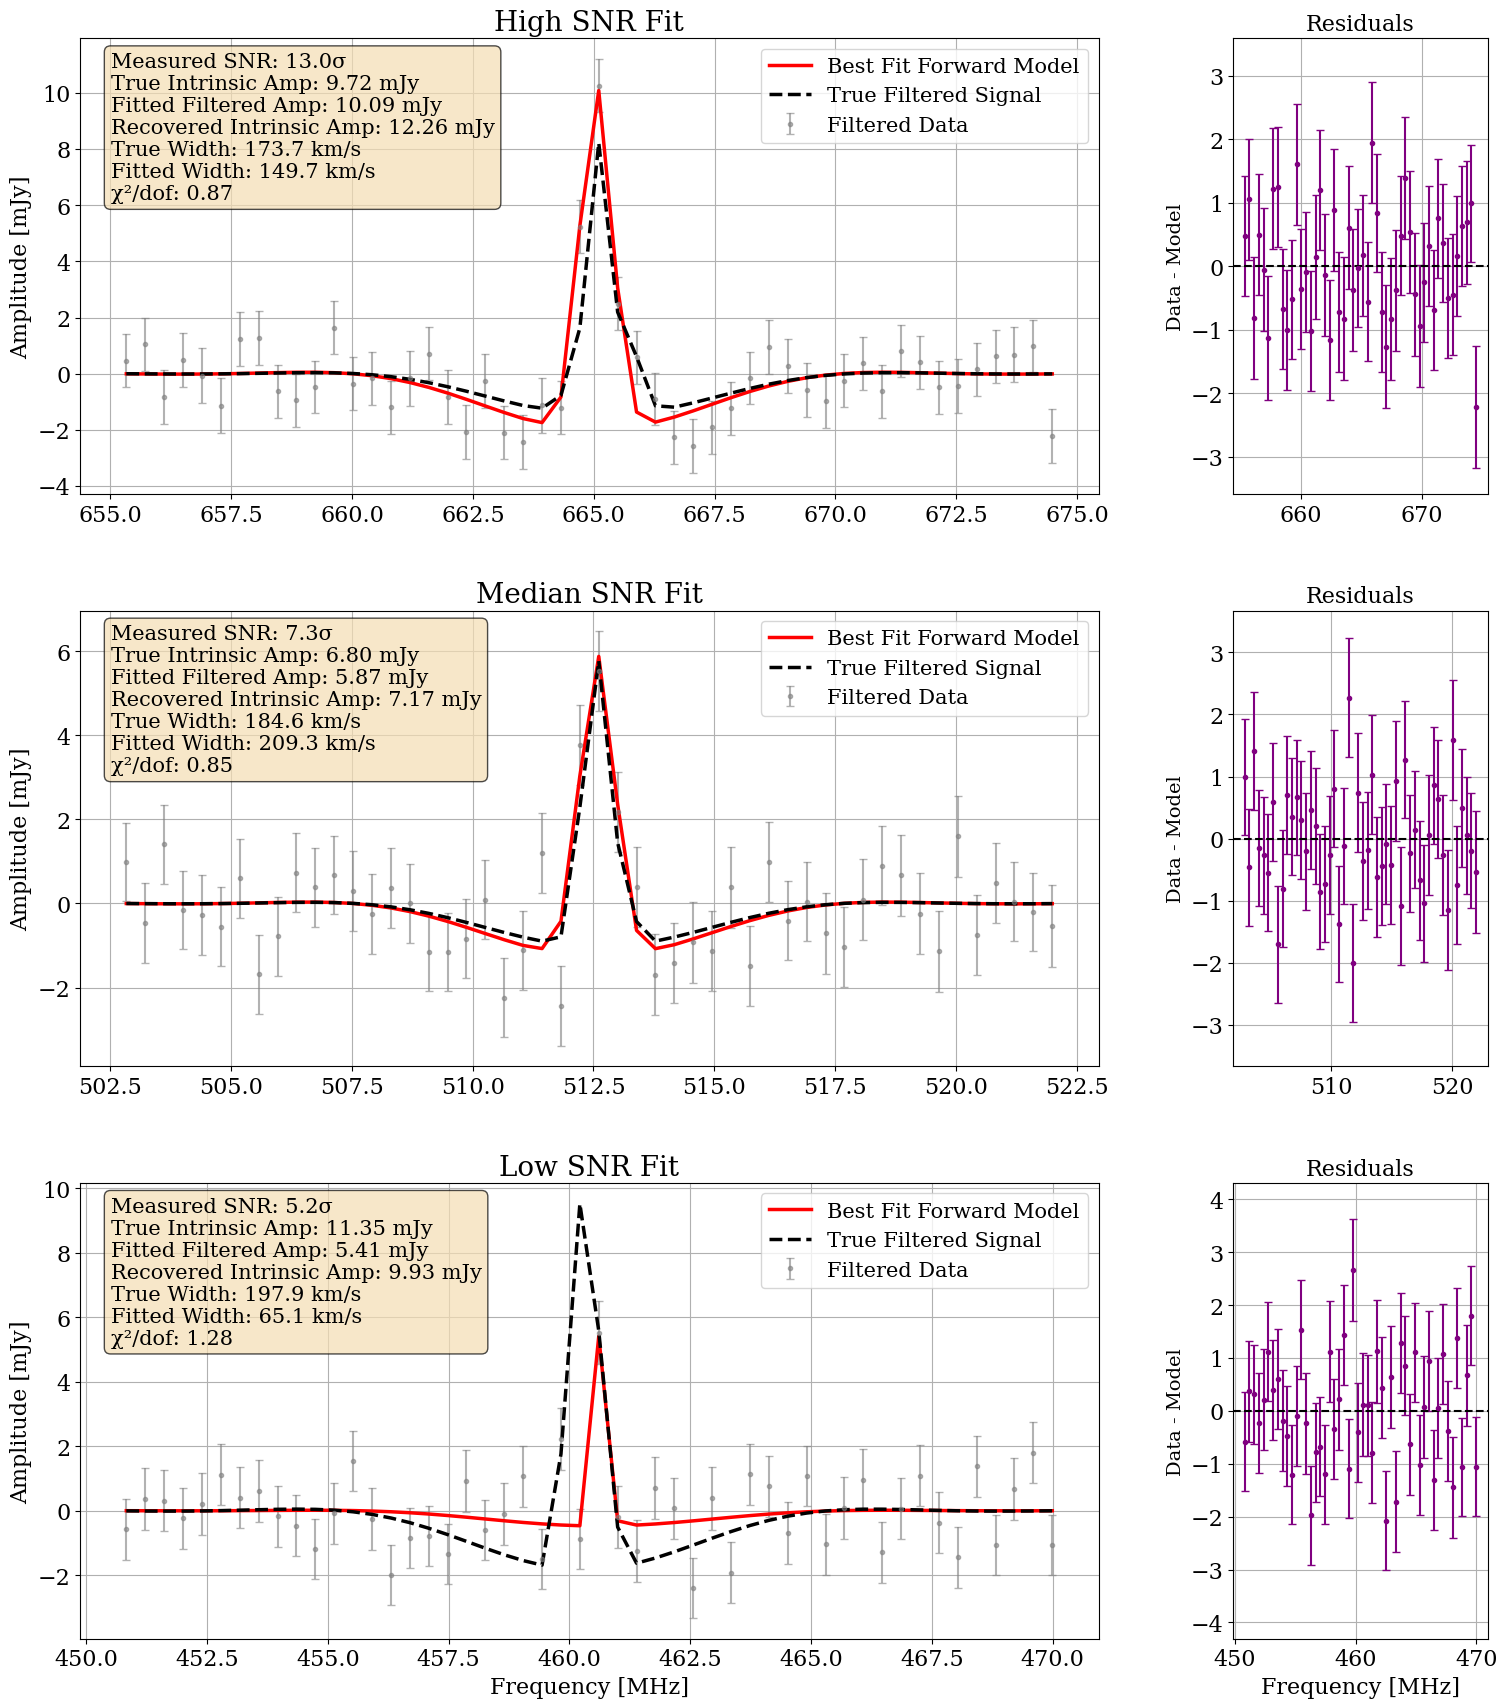

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c
from tqdm.auto import tqdm

# --- 1. Helper Functions ---
def calculate_profile_width(profile, freqs):
    if np.sum(profile) <= 0: return 0
    mean_freq = np.sum(profile * freqs) / np.sum(profile)
    variance = np.sum(profile * (freqs - mean_freq)**2) / np.sum(profile)
    return np.sqrt(np.maximum(0, variance))

def width_mhz_to_kms(width_mhz: float, center_freq_mhz: float) -> float:
    c_kms = c / 1000.0
    return c_kms * (width_mhz / center_freq_mhz)

# --- 2. Find True Positives (Self-Contained) ---
print("--- Finding and Matching Candidates to Identify True Positives ---")
found_candidates = ocf.find_candidates_3d_dbscan(
    snr_cube=snr_cube_3d.reshape(GRID_SHAPE + (N_CHANNELS,)),
    snr_threshold=5.0, eps=11, min_samples=1, freqs_mhz=FREQS_MHZ
)
matched_results = ocf.match_candidates_to_truth_3d(
    candidates=found_candidates, ground_truth=ground_truth,
    grid_shape=GRID_SHAPE, freqs_mhz=FREQS_MHZ
)
true_positives = matched_results['true_positives']
print(f"  - Found {len(true_positives)} true positives to be fitted.")

# --- 3. Fit All True Positives with the Forward Model ---
print(f"\n--- Fitting {len(true_positives)} True Positives with Forward Model ---")
fit_results_fm = []
for match in tqdm(true_positives, desc="Fitting Forward Models"):
    fit_params, fit_errs = ocf.fit_candidate_forward_model(
        candidate=match['cand'], data_cube=delay_filtered_cube,
        noise_spectrum=noise_spectrum, freqs_mhz=FREQS_MHZ,
        delay_filter_func=oss.apply_windowed_delay_filter,
        delay_cut_ns=DELAY_CUT_NS, N_PIX_X=GRID_SHAPE[1]
    )
    if fit_params:
        fit_results_fm.append({
            'fit_params': fit_params, 'fit_errs': fit_errs,
            'candidate_info': match['cand'], 'ground_truth_info': match['inj']
        })
print(f"\nSuccessfully performed forward-model fit on {len(fit_results_fm)} candidates.")

# --- 4. Select and Plot High, Median, and Low SNR Fits ---
if not fit_results_fm:
    print("\nNo successful fits to visualize.")
else:
    print("\n--- Displaying Fits for Highest, Median, and Lowest SNR Detections ---")
    
    sorted_fits = sorted(fit_results_fm, key=lambda x: x['candidate_info']['peak_snr'])
    indices_to_plot = [len(sorted_fits) - 1, len(sorted_fits) // 2, 2]
    labels = ["High SNR Fit", "Median SNR Fit", "Low SNR Fit"]
    fits_to_plot = [sorted_fits[i] for i in indices_to_plot]

    fig, axes = plt.subplots(len(fits_to_plot), 2, figsize=(16, 6 * len(fits_to_plot)),
                             gridspec_kw={'width_ratios': [4, 1]})
    if len(fits_to_plot) == 1: axes = np.array([axes])

    for i, fit_info in enumerate(fits_to_plot):
        ax_main, ax_resid = axes[i, 0], axes[i, 1]
        candidate, ground_truth_info, fit_params = fit_info['candidate_info'], fit_info['ground_truth_info'], fit_info['fit_params']
        
        pixel_idx = ground_truth_info['pixel_index']
        print(pixel_idx)
        freq_idx = np.argmin(np.abs(FREQS_MHZ - candidate['centroid_z_freq']))
        padding = 25
        start, end = max(0, freq_idx - padding), min(len(FREQS_MHZ), freq_idx + padding)
        
        freqs_slice, data_slice, noise_slice = FREQS_MHZ[start:end], delay_filtered_cube[pixel_idx, start:end], noise_spectrum[start:end]
        
        intrinsic_model_full = ocf.gaussian_model(FREQS_MHZ, **{k: v for k, v in fit_params.items() if k != 'chi2_red'})
        fit_curve_filtered = oss.apply_windowed_delay_filter(
            spectrum=intrinsic_model_full, weights=np.ones(N_CHANNELS),
            freqs_mhz=FREQS_MHZ, delay_cut_ns=DELAY_CUT_NS
        )[start:end]

        filtered_true_signal = oss.apply_windowed_delay_filter(
            spectrum=ground_truth_info['noiseless_profile'], weights=np.ones(N_CHANNELS),
            freqs_mhz=FREQS_MHZ, delay_cut_ns=DELAY_CUT_NS
        )[start:end]

        ax_main.errorbar(freqs_slice, data_slice, yerr=noise_slice, fmt='.', label='Filtered Data', capsize=3, alpha=0.6, color='gray')
        ax_main.plot(freqs_slice, fit_curve_filtered, 'r-', lw=2.5, label='Best Fit Forward Model')
        ax_main.plot(freqs_slice, filtered_true_signal, color='k', linestyle='--', lw=2.5, label='True Filtered Signal')

        ax_main.set_title(f"{labels[i]}", fontsize=20)
        ax_main.set_ylabel("Amplitude [mJy]", fontsize=16)
        ax_main.legend(fontsize=15); ax_main.grid(True)

        # --- Calculate widths and create annotation box ---
        peak_filtered_amp = np.max(fit_curve_filtered)
        true_width_mhz = calculate_profile_width(ground_truth_info['noiseless_profile'], FREQS_MHZ)
        true_center_freq = np.sum(ground_truth_info['noiseless_profile'] * FREQS_MHZ) / np.sum(ground_truth_info['noiseless_profile'])
        true_width_kms = width_mhz_to_kms(true_width_mhz, true_center_freq)
        fitted_width_mhz = fit_params['stddev']
        fitted_center_freq = fit_params['mean']
        fitted_width_kms = width_mhz_to_kms(fitted_width_mhz, fitted_center_freq)

        fit_text = (f"Measured SNR: {candidate['peak_snr']:.1f}σ\n"
                    f"True Intrinsic Amp: {ground_truth_info['amp']:.2f} mJy\n"
                    f"Fitted Filtered Amp: {peak_filtered_amp:.2f} mJy\n"
                    f"Recovered Intrinsic Amp: {fit_params['amp']:.2f} mJy\n"
                    f"True Width: {true_width_kms:.1f} km/s\n"
                    f"Fitted Width: {fitted_width_kms:.1f} km/s\n"
                    f"χ²/dof: {fit_params['chi2_red']:.2f}")
        ax_main.text(0.03, 0.97, fit_text, transform=ax_main.transAxes, fontsize=15,
                     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
        
        # Plot residuals
        residuals = data_slice - fit_curve_filtered
        ax_resid.errorbar(freqs_slice, residuals, yerr=noise_slice, fmt='.', capsize=3, color='purple')
        ax_resid.axhline(0, color='black', linestyle='--'); ax_resid.set_title("Residuals", fontsize=16)
        ax_resid.set_ylabel("Data - Model", fontsize=14); ax_resid.grid(True)
        max_resid = np.max(np.abs(residuals)); ax_resid.set_ylim(-max_resid*1.618, max_resid*1.618)

    axes[-1, 0].set_xlabel("Frequency [MHz]", fontsize=16)
    axes[-1, 1].set_xlabel("Frequency [MHz]", fontsize=16)
    plt.tight_layout(pad=2.5)
    fig.savefig('gaussian_fits.jpeg', dpi=150)
    plt.show()

In [39]:
# pick the higest SNR maser
# ground_truth['injections'][171]

In [40]:
def find_injection_index_loop(data, target_pixel):
    """Find the injection index (list position) of a specific pixel number."""
    for injection_index, entry in enumerate(data):
        if entry['pixel_index'] == target_pixel:
            return injection_index
    return None  # Return None if pixel not found

In [41]:
find_injection_index_loop(ground_truth['injections'], 1289)

171

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c
from scipy.optimize import minimize
import emcee
import corner

# --- 1. Define Helper Functions and Constants ---
C_KMS = c / 1000.0
NU_1667_REST = 1667.359
NU_1665_REST = 1665.4018

def fwhm_to_sigma(fwhm):
    return fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))

def gaussian(x, mu, sigma, amp):
    return amp * np.exp(-0.5 * ((x - mu) / sigma)**2)

# --- 2. Define the 6-Parameter Physical Forward Model ---
# (The forward_model_mcmc function and Bayesian framework remain the same)
def forward_model_mcmc(theta, z, vel_axis_kms, freqs_mhz, delay_filter_func, delay_cut_ns):
    total_amp, fwhm_1667, fwhm_1665, fwhm_broad, r_1667_1665, r_broad_1667 = theta
    sigma_1667, sigma_1665, sigma_broad = fwhm_to_sigma(fwhm_1667), fwhm_to_sigma(fwhm_1665), fwhm_to_sigma(fwhm_broad)
    vel_sep_kms = C_KMS * (NU_1667_REST - NU_1665_REST) / NU_1667_REST
    amp_1667_norm, amp_1665_norm, amp_broad_norm = 1.0, 1.0 / r_1667_1665, 1.0 * r_broad_1667
    spec_1667 = gaussian(vel_axis_kms, 0.0, sigma_1667, amp_1667_norm)
    spec_1665 = gaussian(vel_axis_kms, -vel_sep_kms, sigma_1665, amp_1665_norm)
    spec_broad = gaussian(vel_axis_kms, 0.0, sigma_broad, amp_broad_norm)
    intrinsic_profile = (spec_1667 + spec_1665 + spec_broad)
    if np.max(intrinsic_profile) > 0:
        intrinsic_profile /= np.max(intrinsic_profile)
    intrinsic_profile *= total_amp
    projected, s, e = otg.process_to_native_resolution_and_target_z(
        intrinsic_profile, vel_axis_kms, z, freqs_mhz
    )
    if projected.size == 0: return np.zeros_like(freqs_mhz)
    full_model = otg.create_full_spectrum_template(projected, s, e, len(freqs_mhz))
    return delay_filter_func(full_model, np.ones_like(freqs_mhz), freqs_mhz, delay_cut_ns)

# --- 3. Define the Bayesian Framework ---
# We will define the priors later, after the pre-fit.
def log_likelihood(theta, z, y, yerr):
    model = forward_model_mcmc(theta, z, VEL_AXIS, FREQS_MHZ, oss.apply_windowed_delay_filter, DELAY_CUT_NS)
    chi2 = np.sum(((y - model) / yerr)**2)
    return -0.5 * chi2

def log_probability(theta, z, y, yerr, param_bounds):
    # Log-prior is now a simple bounds check
    for i, val in enumerate(theta):
        low, high = param_bounds[i]
        if not (low < val < high):
            return -np.inf
    # If priors are met, return the log-likelihood
    return log_likelihood(theta, z, y, yerr)

# --- 4. Select Signal and Run Pre-Fit to Constrain Amplitude ---
print("--- Preparing data and running pre-fit for MCMC analysis ---")
injection_index = 171 #25
g_truth = ground_truth['injections'][injection_index]
pixel_idx, true_z = g_truth['pixel_index'], g_truth['z']
data_to_fit = delay_filtered_cube[pixel_idx, :]
errors = noise_spectrum

# Get the true parameters for later comparison
p0_true_6d = [
    g_truth['amp'], g_truth['fwhm_1667'], g_truth['fwhm_1665'],
    g_truth['fwhm_broad'], g_truth['amp_ratio_1667_over_1665'],
    g_truth['amp_ratio_broad_over_1667']
]

# Define a simple objective function for the pre-fit (negative log-likelihood)
def neg_log_like(theta, z, y, yerr):
    return -log_likelihood(theta, z, y, yerr)

# Pre-fit the data using a simple optimizer to find the peak of the likelihood
result = minimize(neg_log_like, x0=p0_true_6d, args=(true_z, data_to_fit, errors), method='Nelder-Mead')
best_fit_params = result.x
print(f"  - Pre-fit found best amplitude: {best_fit_params[0]:.2f} Jy")

# --- 5. Run the MCMC Sampler with Tighter Priors ---
print("\n--- Running MCMC sampler with robust initialization ---")
n_walkers, n_dim, n_steps, burn_in = 55, 6, 7000, 1500

# Create new, tighter bounds for the amplitude based on the pre-fit
amp_bound = (g_truth['amp'] - .1, g_truth['amp'] + .1) #(best_fit_params[0] * 0.5, best_fit_params[0] * 1.5)
param_bounds_tight = [amp_bound] + [(30, 150), (30, 150), (100, 400), (1.8, 7.0), (0.1, 0.5)] # made this more even

# Initialize walkers randomly within these tighter prior bounds
p0 = np.zeros((n_walkers, n_dim))
for i in range(n_dim):
    low, high = param_bounds_tight[i]
    p0[:, i] = np.random.uniform(low, high, n_walkers)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability, args=(true_z, data_to_fit, errors, param_bounds_tight));
sampler.run_mcmc(p0, n_steps, progress=True);

--- Preparing data and running pre-fit for MCMC analysis ---
  - Pre-fit found best amplitude: 22.16 Jy

--- Running MCMC sampler with robust initialization ---


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7000/7000 [10:08<00:00, 11.51it/s]



--- Generating final corner plot of the posterior distributions ---


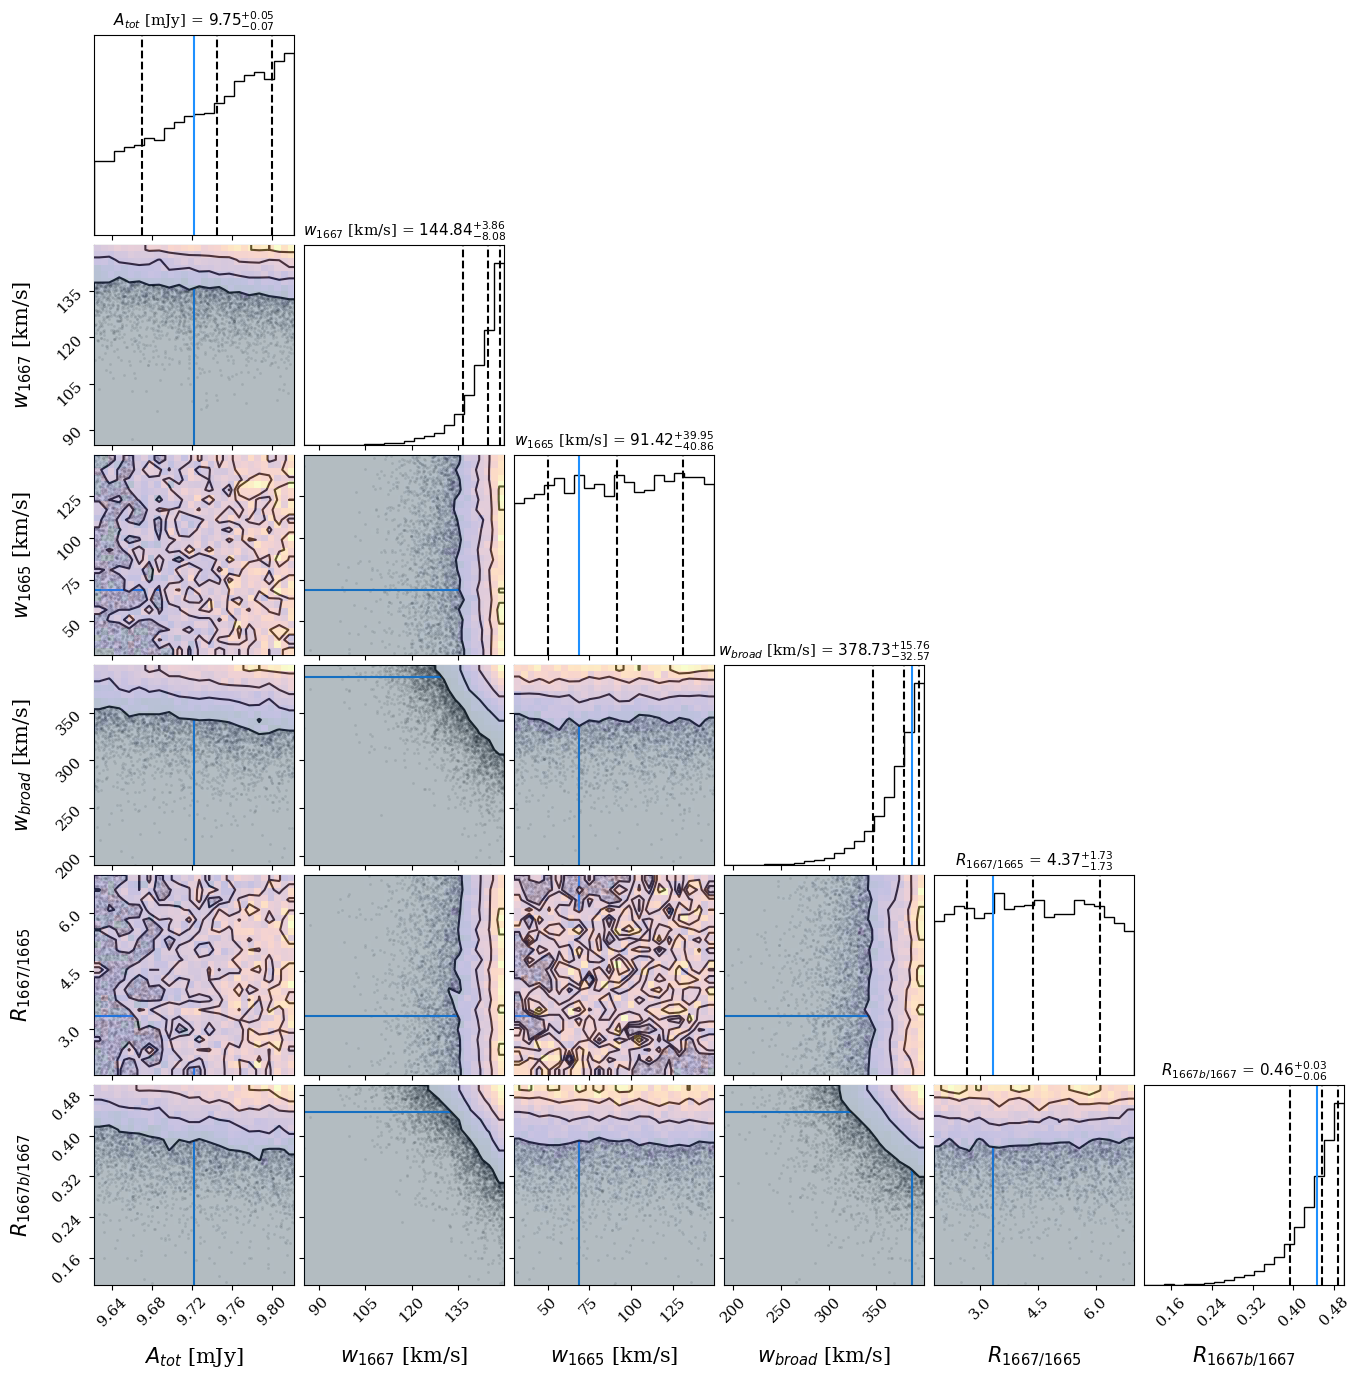


--- Final Parameter Recovery Errors ---
Parameter       | True Value   | Median Fit   | Relative Error (%)
-----------------------------------------------------------------
$A_{tot}$ [mJy] | 9.72         | 9.75         | +0.24%
$w_{1667}$ [km/s] | 82.12        | 144.84       | +76.37%
$w_{1665}$ [km/s] | 68.62        | 91.42        | +33.22%
$w_{broad}$ [km/s] | 387.23       | 378.73       | -2.19%
$R_{1667/1665}$ | 3.32         | 4.37         | +31.76%
$R_{1667b/1667}$ | 0.45         | 0.46         | +2.45%


In [43]:
# --- 6. Generate the Final Corner Plot ---
print("\n--- Generating final corner plot of the posterior distributions ---")
flat_samples = sampler.get_chain(discard=burn_in, thin=15, flat=True)
labels_6d = [r"$A_{tot}$ [mJy]", r"$w_{1667}$ [km/s]", r"$w_{1665}$ [km/s]", r"$w_{broad}$ [km/s]", r"$R_{1667/1665}$", r"$R_{1667b/1667}$"]

fig = corner.corner(
    flat_samples, 
    labels=labels_6d, 
    truths=p0_true_6d, 
    quantiles=[0.16, 0.5, 0.84], 
    color='k',
    truth_color='dodgerblue',
    show_titles=True, 
    title_kwargs={"fontsize": 11}, 
    label_kwargs={"fontsize": 15}, 
    tick_kwargs={'labelsize': 11},
    plot_contours=True, 
    fill_contours=False,  # Changed to True
    contour_kwargs={'alpha': 0.88},  # Make contours semi-transparent
    density=True, 
    cmap=cmocean.cm.thermal,
    plot_density=False,  # Turn off default density plotting
)

# Add colored 2D histogram backgrounds
import numpy as np
ndim = flat_samples.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(i):
        ax = axes[i, j]
        
        # Get data for this pair
        x_data = flat_samples[:, j]
        y_data = flat_samples[:, i]
        
        # Add 2D histogram background with same colormap
        h = ax.hist2d(x_data, y_data, bins=30, cmap=cmocean.cm.thermal, alpha=0.3, zorder=0)
        
        # Ensure contours are on top
        for collection in ax.collections:
            collection.set_zorder(10)

# Adjust tick labels
for ax in fig.get_axes():
    ax.tick_params(labelsize=11)
            
plt.show()

# --- 7. Print Final Parameter Errors ---
print("\n--- Final Parameter Recovery Errors ---")
median_fit = np.percentile(flat_samples, 50, axis=0)
print(f"{'Parameter':<15} | {'True Value':<12} | {'Median Fit':<12} | {'Relative Error (%)'}")
print("-" * 65)
for i in range(n_dim):
    true_val = p0_true_6d[i]
    fit_val = median_fit[i]
    rel_error = ((fit_val - true_val) / true_val) * 100
    print(f"{labels_6d[i]:<15} | {true_val:<12.2f} | {fit_val:<12.2f} | {rel_error:+.2f}%")

In [44]:
fig.savefig('MCMC_corner_plot.jpeg', dpi=150)